## Load Packages

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

# formatting
import re
def add_comma(match):
    return match.group(0) + ','

#Preprocessing
from scipy.stats import pearsonr, mode 
from numpy import nanmean, nanstd

# plots
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

# #add folder to path for custom module imports
# import sys
# sys.path.append("scripts")

#custom functions
from functions import getResponses, chooseData, chooseEmb, getEmbeddings, getData, predModel, corrUserBased #general auxiliary function
from functions import compareModels, modelPerformance, comparePerformance #model training and comparison
from functions import regCorr, mean_confidence_interval, pearsonr_ci, welch_t_test #human judges comparison
from functions import predictionPerformance

#random state
randState = 0

#warning messages
import warnings
warnings.filterwarnings("ignore", message="An input array is constant; the correlation coefficient is not defined.")

## Analyze Performance

### Calculate model performances (only run once/if not already saved)

16PF

In [ ]:
#calculate model performance (only needs to run once)
modelPerformance(m=4, par=5, d="16PF", e="sentencebert", verbose=1) #fit a single model with specified parameter, report performance
#m -> #0: Ridge regression, #1: RidgeClass, #2:KNN, #3: Kernel SVC (RBF), #4: KNN Regression

#baseline: Word2Vec
modelPerformance(m=3, par=10, d="16PF", e="word2vec", verbose=1) #fit a single model with specified parameter, report performance

#baseline: LIWC
modelPerformance(m=0, par=10, d="16PF", e="liwc", verbose=1) #fit a single model with specified parameter, report performance

RIASEC

In [ ]:
#calculate model performance (only needs to run once)
modelPerformance(m=4, par=5, d="RIASEC", e="sentencebert", verbose=1) #fit a single model with specified parameter, report performance
#m -> #0: Ridge regression, #1: RidgeClass, #2:KNN, #3: Kernel SVC (RBF), #4: KNN Regression

#baseline: Word2Vec
modelPerformance(m=3, par=10, d="RIASEC", e="word2vec", verbose=1) #fit a single model with specified parameter, report performance

#baseline: LIWC
modelPerformance(m=0, par=10, d="RIASEC", e="liwc", verbose=1) #fit a single model with specified parameter, report performance

HSQ

In [ ]:
#calculate model performance (only needs to run once)
modelPerformance(m=4, par=5, d="HSQ", e="sentencebert", verbose=1) #fit a single model with specified parameter, report performance
#m -> #0: Ridge regression, #1: RidgeClass, #2:KNN, #3: Kernel SVC (RBF), #4: KNN Regression

#baseline: Word2Vec
modelPerformance(m=3, par=10, d="HSQ", e="word2vec", verbose=1) #fit a single model with specified parameter, report performance

#baseline: LIWC
modelPerformance(m=0, par=10, d="HSQ", e="liwc", verbose=1) #fit a single model with specified parameter, report performance

### Load model performances (run instead of section above -- much faster)

In [3]:
datasets = ["16PF", "RIASEC", "HSQ"]

for d in datasets:
    #Choose Data Set:
    R = 2           #1: reversed-coded, #2: nonReversed-coded

    #best Model (KnnRegression k=5, no reverse-coding):
    m = 4          #0: Ridge, #1: RidgeClass, #2:KNN, #3: Kernel SVM (RBF), #4: KNN regression
    par = 5
    e = 'sentencebert'
    model, modelName = predModel(m,par)

    #load path and necessary variables:
    folder, data = chooseData(d)        
    embeddings, save = chooseEmb(e)     #LIWC, WORD2VEC, SENTENCEBERT
    responses, savePath, items, _ = getResponses(folder, data, R) #1: Reversed, #2: nonReversed
    responses = responses.astype(float) #get observed responses as floats
    X, X_stand, X_pca_stand = getEmbeddings(folder, data, embeddings, responses)

    #get embeddings name:
    embName = embeddings.split("_")[2].split(".")[0]

    # import required data and labels
    data_q, constructs_list, list_par, constrAssigned = getData(m, responses, X_pca_stand, folder, data)

    # get predicted responses of chosen model:
    total_preds = pd.read_csv(savePath + modelName + "_" + str(par) + "_" + embName + "_responses.csv", index_col=0)
    total_preds.index = total_preds.index.map(str)
    total_preds = total_preds.astype(float)

    #get model performance:
    corr, means = corrUserBased(total_preds, responses)
    print("Dataset: " + d.upper())
    print("Correlation, lower-CI, upper-CI, p-value, t-statistic, DOF")
    print(list(np.round(means, 3))) #corr, p, l1, ci lower, ci upper, t-stats, df
    print("\n")
    print("Percentage of significant positive correlations: ")
    print(round(np.mean((corr.Correlation>0) & (corr["p-value"]<0.05)), 3))

Dataset: 16PF
Correlation, lower-CI, upper-CI, p-value, t-statistic, DOF
[0.388, 0.0, 0.387, 0.389, 585.486, 49157.0]


Percentage of significant positive correlations: 
0.933
Dataset: RIASEC
Correlation, lower-CI, upper-CI, p-value, t-statistic, DOF
[0.349, 0.0, 0.348, 0.35, 594.911, 135762.0]


Percentage of significant positive correlations: 
0.647
Dataset: HSQ
Correlation, lower-CI, upper-CI, p-value, t-statistic, DOF
[0.34, 0.0, 0.32, 0.36, 33.205, 588.0]


Percentage of significant positive correlations: 
0.514


## Performance Plots (Model & Baselines)

### Calculate performance across data sets

Creates a dataframe with the performance in the response prediction task of each embedding type for all data sets of Study 2

In [11]:
# best performing model:
m   = 4               #0: Ridge, #1: RidgeClass, #2:KNN, #3: Kernel SVM (RBF)
par = 5
e   = 'sentencebert'

model, modelName = predModel(m,par) 

datasets = ['16PF', 'HSQ', 'RIASEC']
performance = pd.DataFrame(columns=["Dataset", "Model", "Correlation", "p-value", "L1 Loss"])
sig_data = []

#iterate through datasets
for i,nr in zip(datasets, range(len(datasets))):
  #add LIWC - Baseline
      #load prediction and baseline data
  folder, data = chooseData(i)
  responses, savePath, items, _ = getResponses(folder, data, 2)
  total_preds = pd.read_csv(savePath + modelName + "_" + str(par) + "_" + e.upper() + "_responses.csv", index_col=0)
  total_dumb = pd.read_csv(savePath + 'baseline_responses.csv', index_col=0) #naive baseline
  responses.index = total_preds.index
      #get performances
  results, resultsMean = corrUserBased(total_preds, responses)
  results_dumb, resultsMean_dumb = corrUserBased(total_dumb, responses)
  results.insert(0,'Model',['Best Model']*results.shape[0])
  results.insert(0,'Dataset',[i]*results.shape[0])
  results_dumb.insert(0,'Model',['Average Response']*results_dumb.shape[0])
  results_dumb.insert(0,'Dataset',[i]*results_dumb.shape[0])
  
  # get percentage of significant positive correlations
  sig_count = results.loc[(results.Correlation > 0) & (results["p-value"]<0.05),:].shape[0]/results.shape[0]
  sig_data.append([i, "SBERT", sig_count])

  #combine correlations of all datasets in one frame
  performance = pd.concat([performance, results], ignore_index = True)

  #add word2vec Baseline
  mName_w2v = "SVC"
  par_w2v = 10
  total_preds3 = pd.read_csv(savePath + mName_w2v + "_" + str(par_w2v) + "_" + "WORD2VEC".upper() + "_responses.csv", index_col=0)
  responses.index = total_preds3.index
      #get performances
  results3, resultsMean2 = corrUserBased(total_preds3, responses)
  results3.insert(0,'Model',['WORD2VEC']*results3.shape[0])
  results3.insert(0,'Dataset',[i]*results3.shape[0])

  # get percentage of significant positive correlations
  sig_count = results3.loc[(results3.Correlation > 0) & (results3["p-value"]<0.05),:].shape[0]/results3.shape[0]
  sig_data.append([i, "WORD2VEC", sig_count])

  #combine correlations of all datasets in one frame
  performance = pd.concat([performance, results3], ignore_index = True)

  #add LIWC -- Baseline
  mName_liwc = "Ridge"
  par_liwc = 10
  total_preds2 = pd.read_csv(savePath + mName_liwc + "_" + str(par_liwc) + "_" + "LIWC".upper() + "_responses.csv", index_col=0)
  responses.index = total_preds2.index
      #get performances
  results2, resultsMean2 = corrUserBased(total_preds2, responses)
  results2.insert(0,'Model',['LIWC']*results.shape[0])
  results2.insert(0,'Dataset',[i]*results.shape[0])
  
  # get percentage of significant positive correlations
  sig_count = results2.loc[(results2.Correlation > 0) & (results2["p-value"]<0.05),:].shape[0]/results2.shape[0]
  sig_data.append([i, "LIWC", sig_count])

  #combine correlations of all datasets in one frame
  performance = pd.concat([performance, results2], ignore_index = True)
  performance = pd.concat([performance, results_dumb], ignore_index = True)

# save results
performance.to_csv("../plot_data/performances_s2.csv")

### Plot from pre-saved data

<Figure size 3600x6480 with 0 Axes>

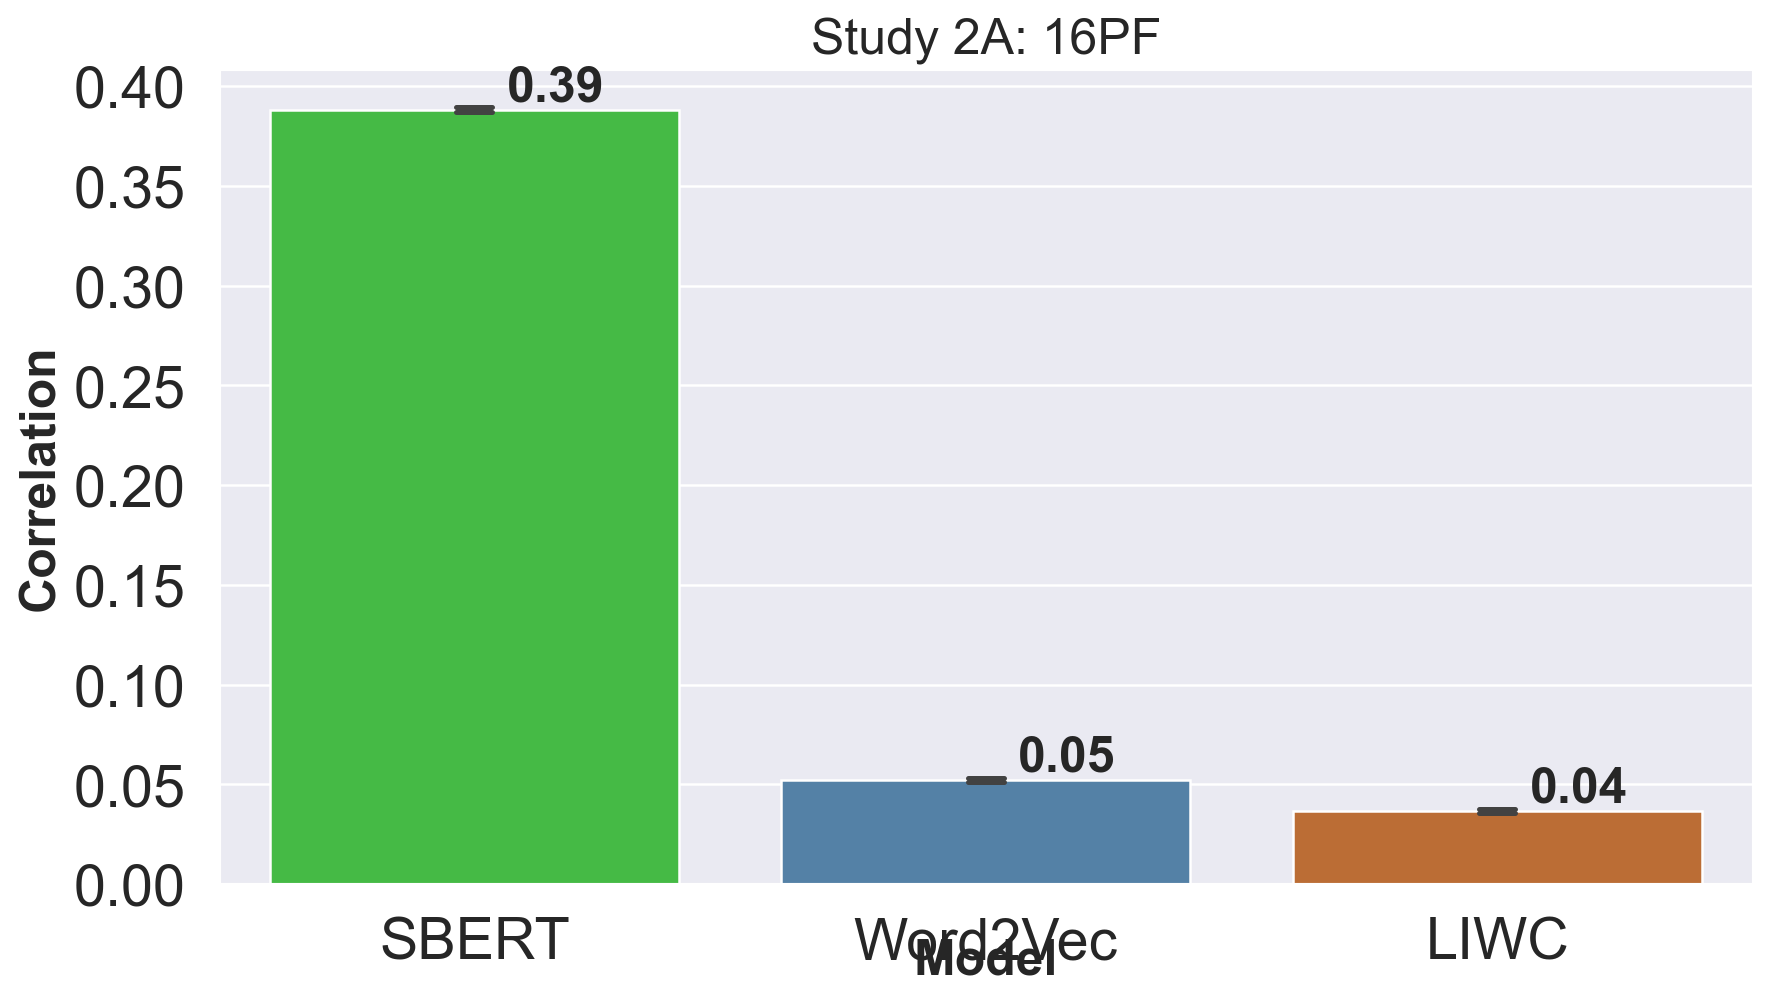

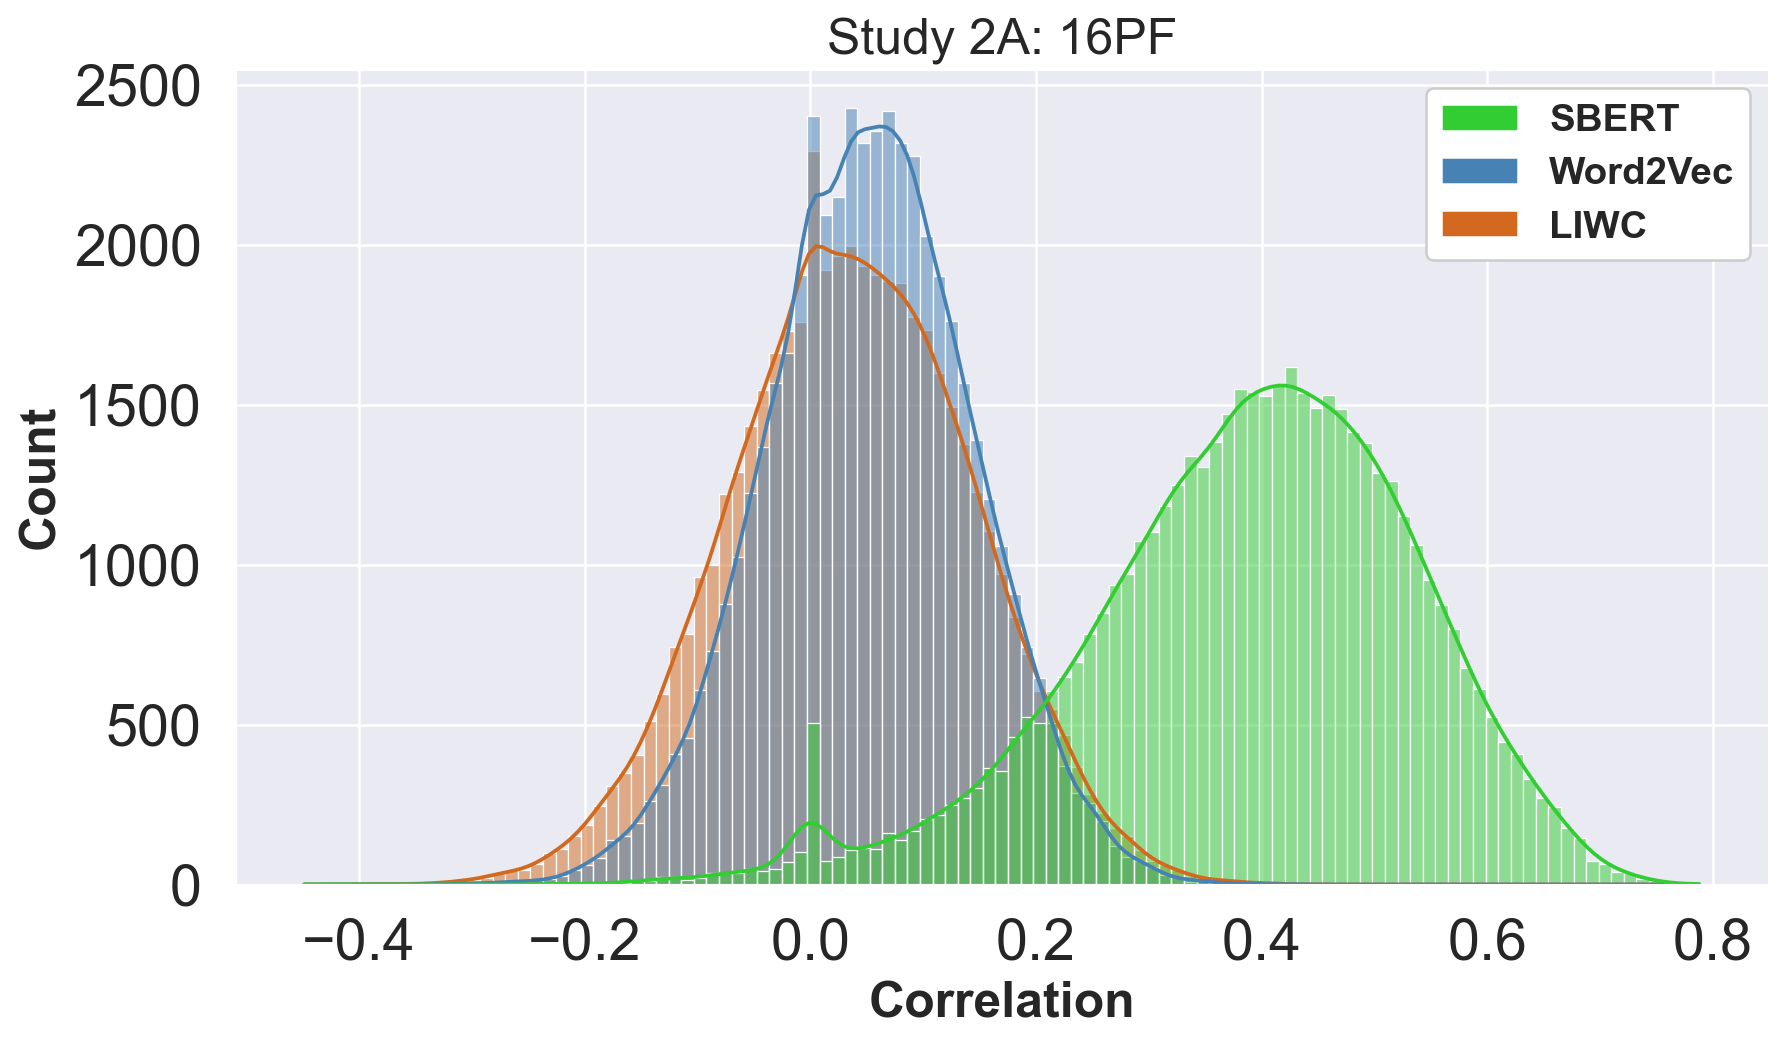

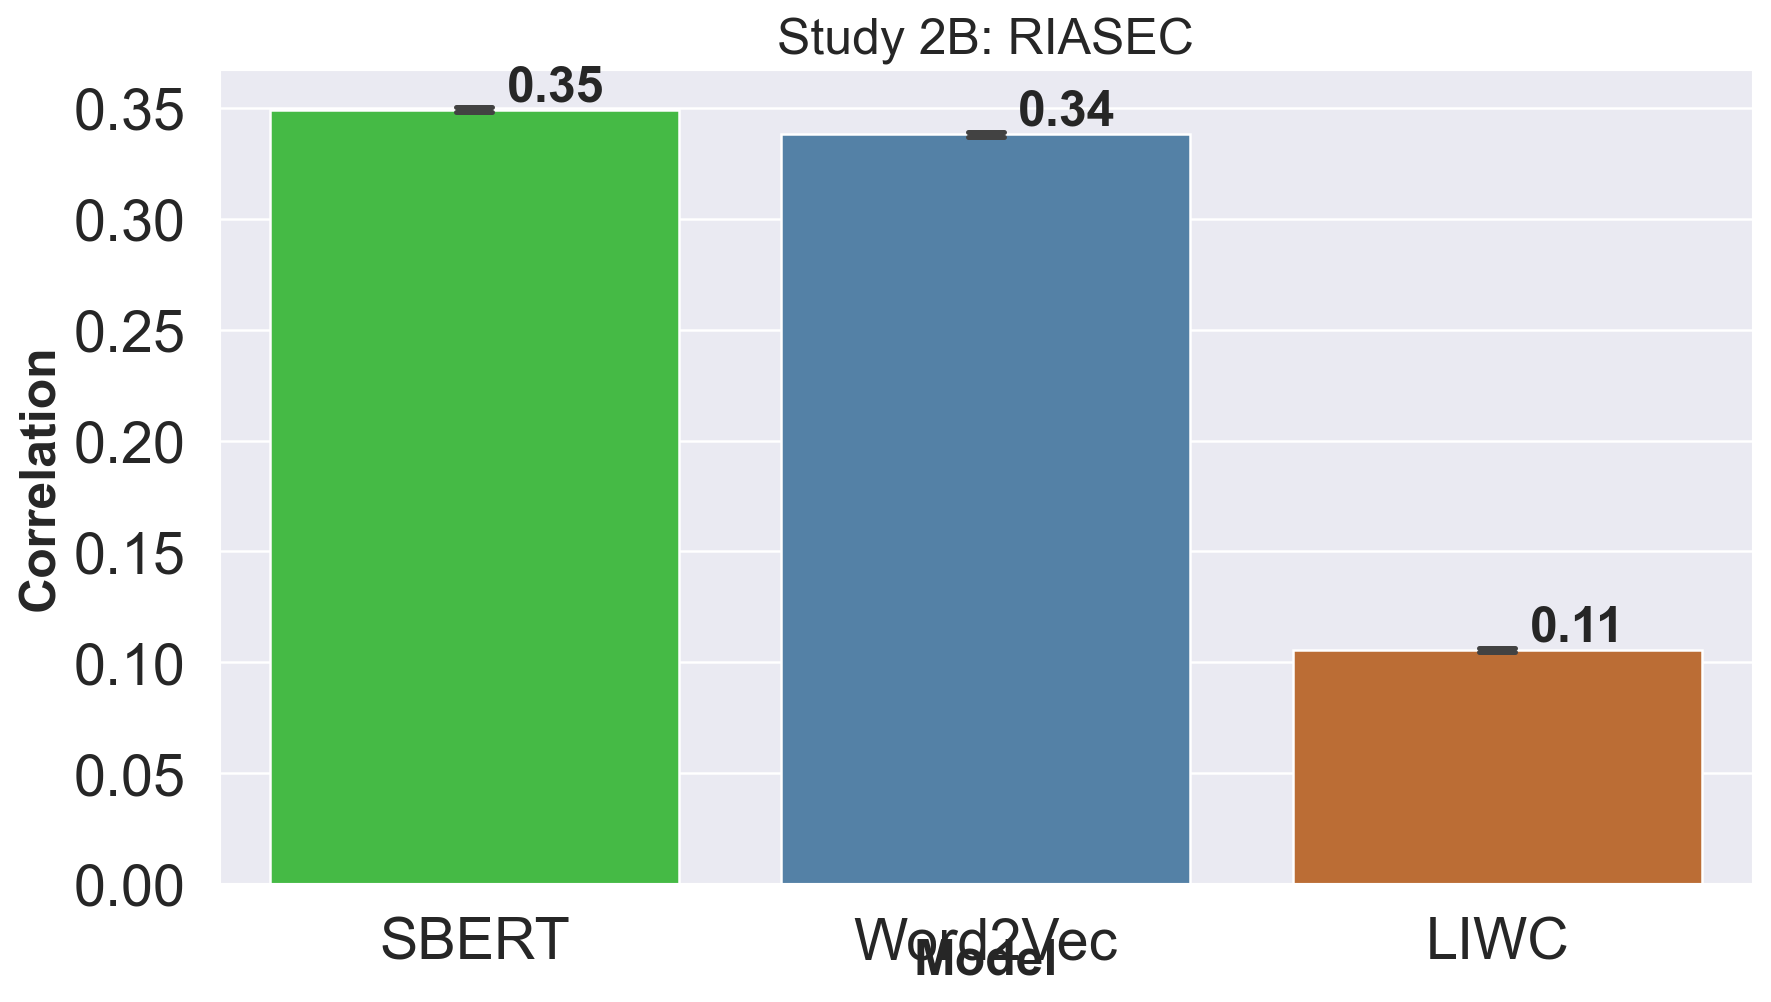

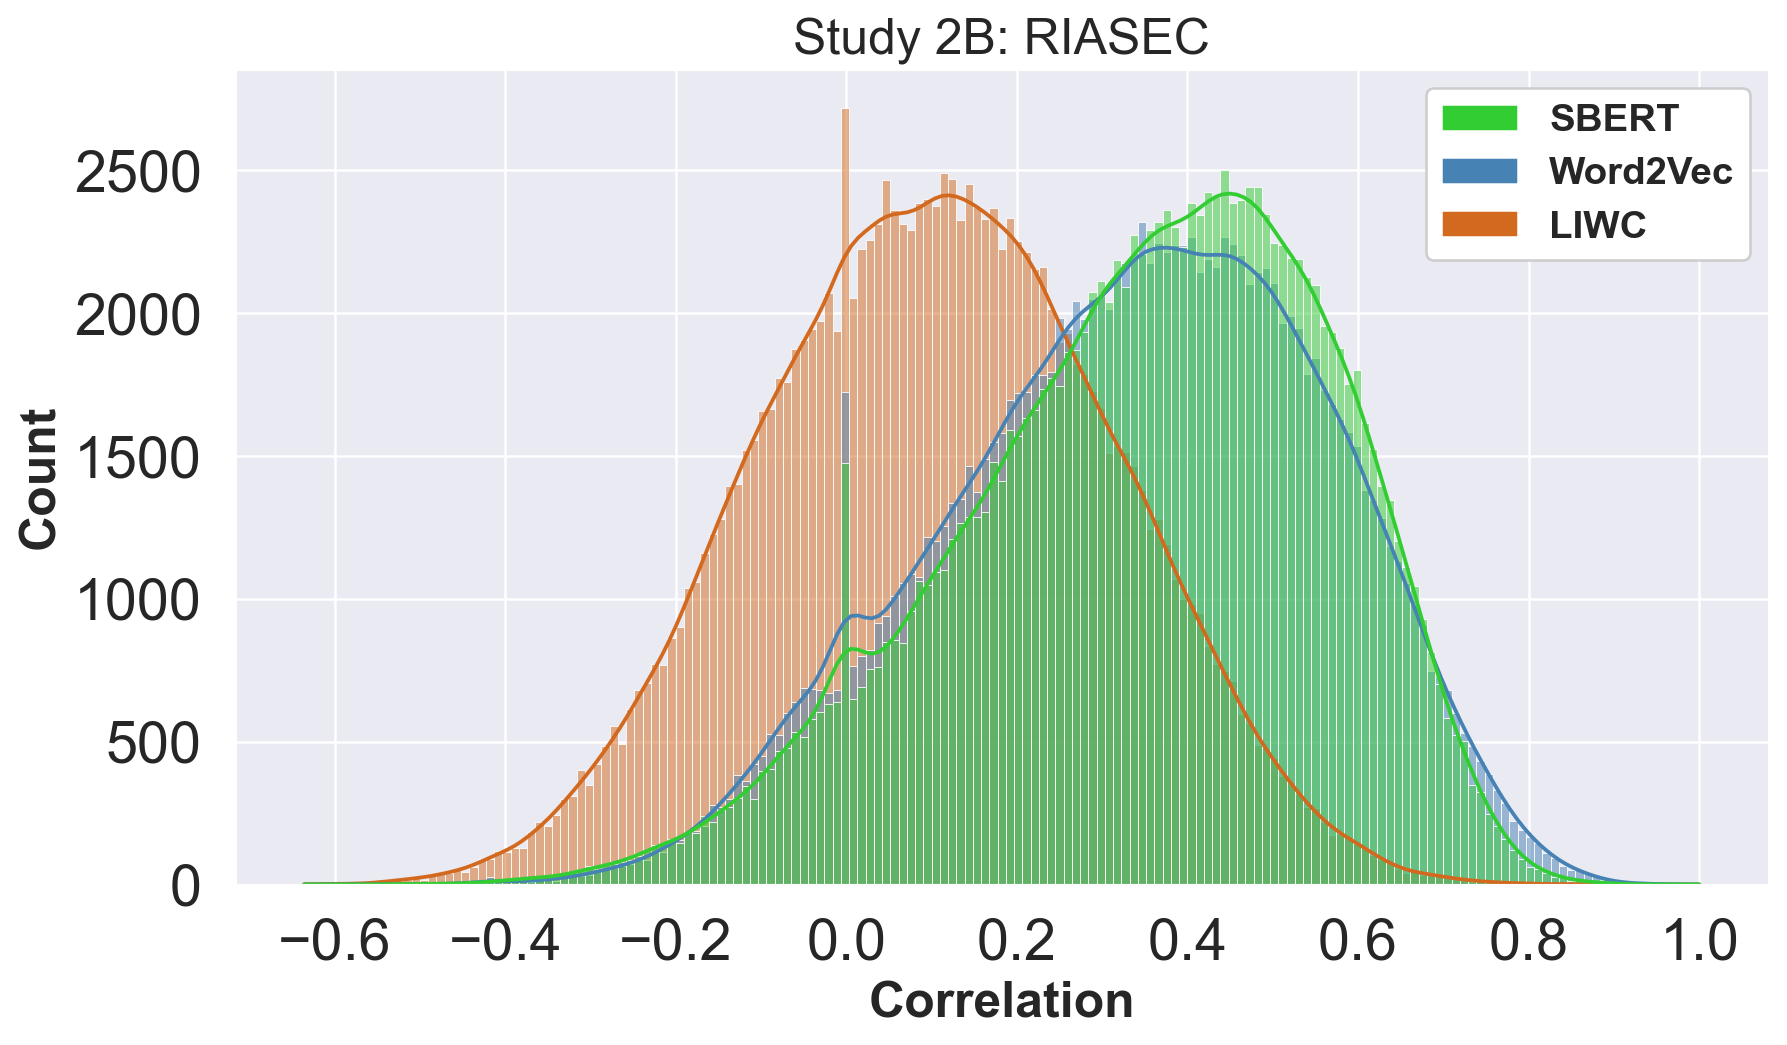

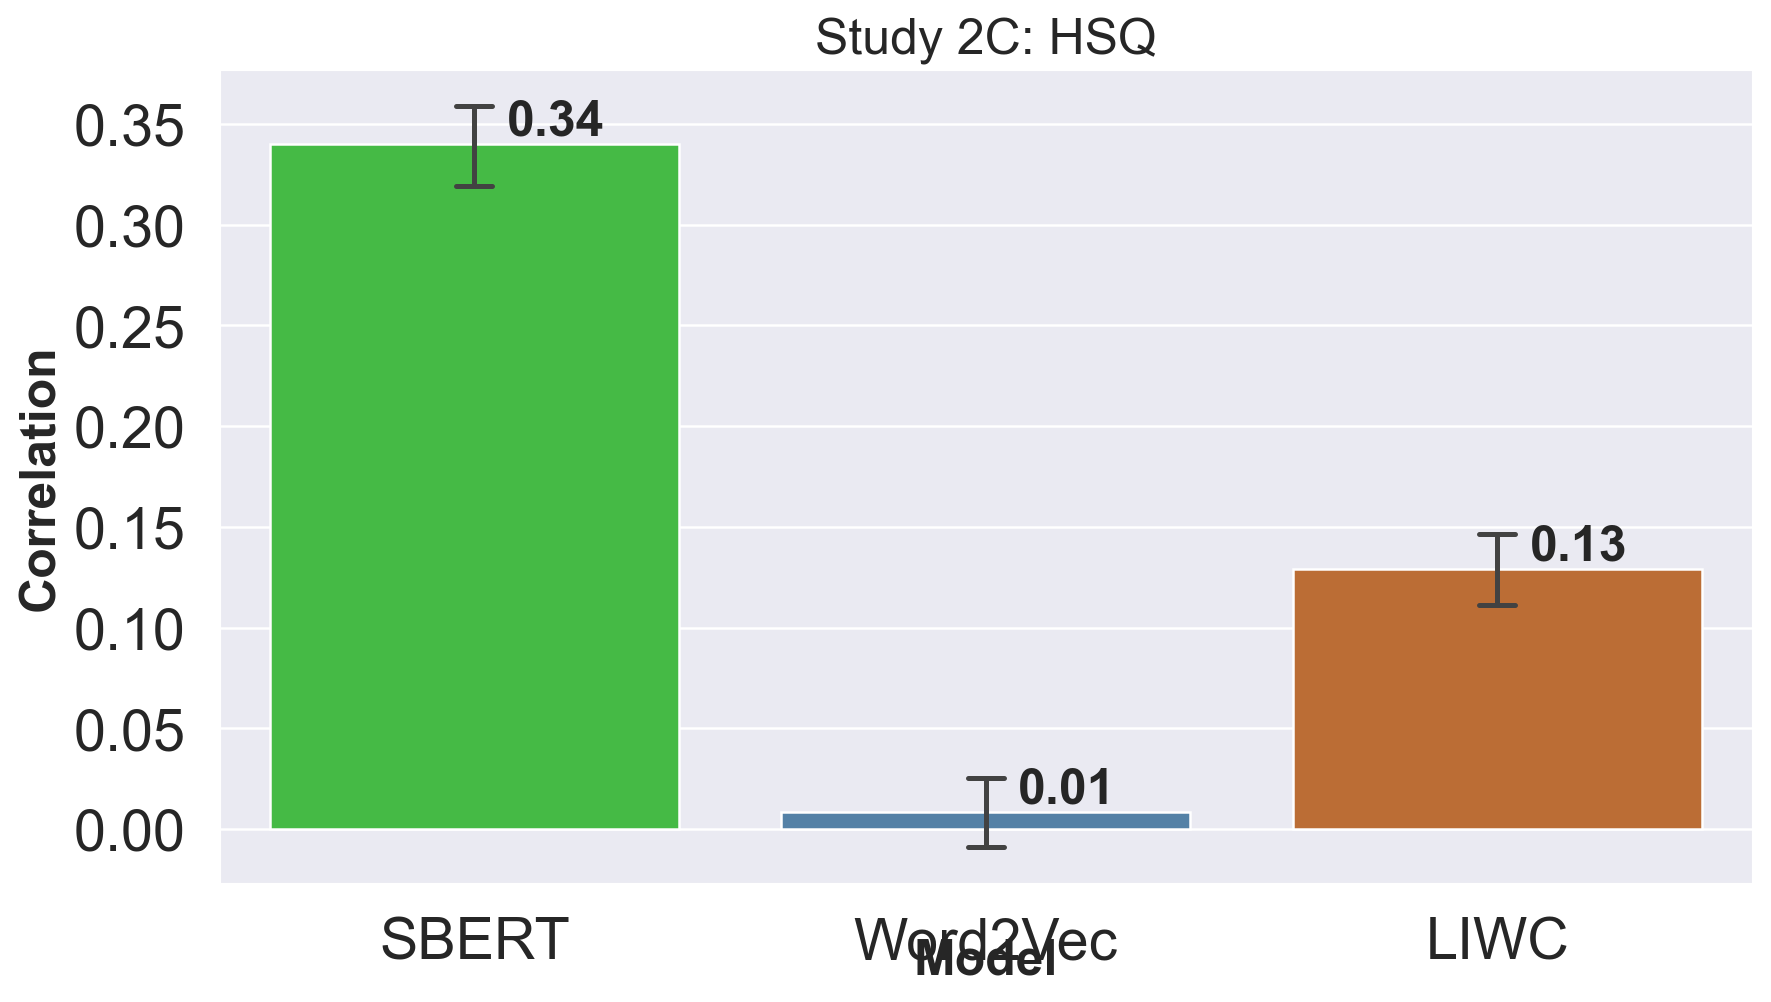

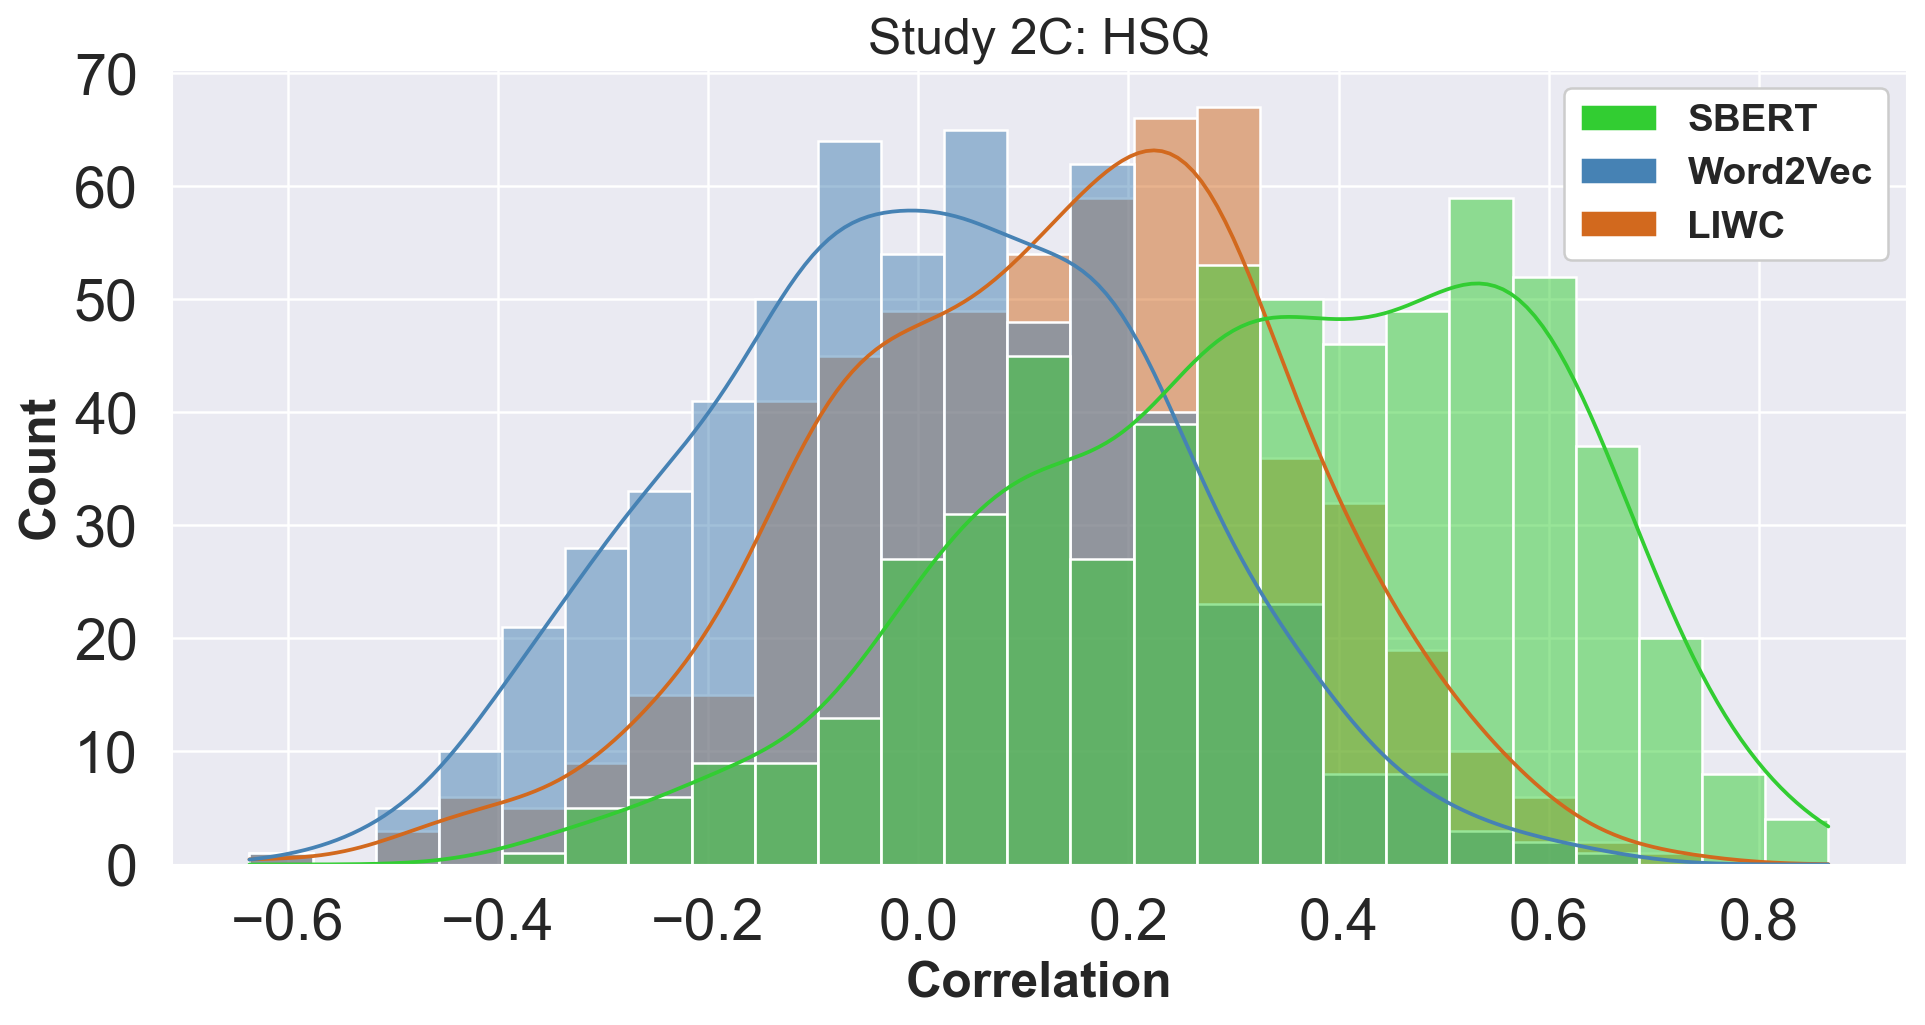

In [13]:
performance = pd.read_csv("../plot_data/performances_s2.csv", index_col=0)

# reshape data frame to show performance for each embedding type
cols = performance.columns.drop(['Dataset', 'Model'])
performance[cols] = performance[cols].astype(float)
performance = pd.melt(performance, id_vars=["Dataset", "Model"],var_name="predictor", value_name="metric value")
plot_data = performance[(performance['predictor'] == 'Correlation')].copy()
plot_data.loc[plot_data.Model == "Best Model", 'Model'] = "SBERT"

# rename for better display in plots
plot_data['Model'] = ["Word2Vec" if item=="WORD2VEC" else item for item in plot_data['Model']]
plot_data['Model'] = ["Average\nResponse" if item=="Average Response" else item for item in plot_data['Model']]

#create plots
fig  = plt.figure(figsize=(20, 36), dpi= 180)
sns.set(font_scale = 1)
order = ['16PF', 'RIASEC', "HSQ"]
dataset_names = ['Study 2A: 16PF', 'Study 2B: RIASEC', "Study 2C: HSQ"]

#Plot style and meta
plt.style.use("seaborn-v0_8")
sns.set_context('paper')
sns.set(font_scale = 1.4)
for i in range(1,4):

    #Add the performance plots:
    data = plot_data[(plot_data.Dataset == order[i-1]) & (plot_data.Model != "Average\nResponse")]
    fig  = plt.figure(figsize=(11, 6), dpi= 180)
    ax = sns.barplot(y='metric value', x='Model', orient='v', data=data, errorbar=('ci', 95), palette=["limegreen","steelblue", "chocolate", "sandybrown"], capsize=0.07, err_kws={'linewidth': 2})
    for p in ax.patches:
      if p.get_height() < 0:
        height = -6
      else:
        height = 6
      ax.annotate("%.2f" % round(p.get_height(),2), xy=(p.get_x() + p.get_width() / 2, p.get_height()),
              xytext=(13, height + 3), textcoords='offset points', ha="left", va="center", fontweight='bold',fontsize=20)
    plt.ylabel("Correlation", fontweight='bold', fontsize=20)
    plt.xlabel("Model", fontweight='bold', fontsize=20, labelpad=-13)
    plt.title(dataset_names[i-1], fontsize=20)
    plt.xticks(fontsize=23)
    plt.yticks(fontsize=23)

    fig_name = "fig2_" + chr(65+2*i) + ".pdf"
    plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')

    #Add the distribution plots for each questionnaire:
    fig  = plt.figure(figsize=(11, 6), dpi= 180)
    palette=["limegreen","steelblue", "chocolate"]
    ax = sns.histplot(data, x="metric value", kde=True, hue="Model", palette = palette)
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=item) for item in palette]
    labels = data.Model.unique().tolist()
    ax.legend(handles = handles, labels = labels, frameon = True, framealpha = 1.0, facecolor='white', prop={'weight':'bold'})

    plt.ylabel("Count", fontweight='bold', fontsize=20)
    plt.xlabel("Correlation", fontweight='bold', fontsize=20)
    plt.title(dataset_names[i-1], fontsize=20)
    plt.xticks(fontsize=23)
    plt.yticks(fontsize=23)

    fig_name = "fig2_" + chr(65+2*i+1) + ".pdf"
    plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')

plt.tight_layout()
plt.subplots_adjust(hspace = 1)
plt.show()

## Human Comparison

### Calculate and print performance overview

Load all necessary data (true target responses, model predictions, human judges ratings, etc.)

In [3]:
# #best Model (KnnRegression k=5, no reverse-coding):
m = 4          #0: Ridge, #1: RidgeClass, #2:KNN, #3: Kernel SVM (RBF), #4: KNN regression
par = 5
e = 'sentencebert'
model, modelName = predModel(m,par)

pars = [m, par, e, model, modelName]

# lists to save the results across datasets (for plotting)
df_comparisons = []

datasets = ["big5", "16pf", "riasec", "hsq"]
dataset_names = ["Study 1: NEO-PI-R", 'Study 2A: 16PF', 'Study 2B: RIASEC', 'Study 2C: HSQ']
df_comparisons = comparePerformance(datasets, dataset_names, pars, df_comparisons)

Get average performance and test for significance (against zero)

In [4]:
for i, df_comparison in enumerate(df_comparisons): #check order
    if i == 0:
        continue
    print("Dataset: " + df_comparison.Dataset[0])
    #humans
    h = df_comparison.loc[df_comparison.Predictor == "Human", "Correlation"].values
    ttest_h = stats.ttest_1samp(h, 0, nan_policy="omit")
    t_h = round(ttest_h[0], 3)
    p_h = round(ttest_h[1], 4)

    #model
    m = df_comparison.loc[df_comparison.Predictor == "Model", "Correlation"].values
    ttest_m = stats.ttest_1samp(m, 0, nan_policy="omit")
    t_m = round(ttest_m[0], 3)
    p_m = round(ttest_m[1], 4)
    
    model  = df_comparison[df_comparison.Predictor == "Model"].dropna()
    humans = df_comparison[df_comparison.Predictor == "Human"].dropna()

    # two-sample independent welch test 
    welch_stat = welch_t_test(np.mean(humans.Correlation), np.std(humans.Correlation, ddof=1), humans.Correlation.size,
                               np.mean(model.Correlation), np.std(model.Correlation, ddof=1), model.Correlation.size)

    ##### Print Results for each questionnaire
    print("Human raters performance across all targets:")
    print("Correlation, t-statistic, p-value, DOF")
    print([round(nanmean(h),3), t_h, p_h, len(h)-2])

    print("\nModel performance across all targets:")
    print("Correlation, t-statistic, p-value, DOF")
    print([round(nanmean(m),3), t_m, p_m, len(m)-2])
    
    print("\n Welch's t-test: Are model and human performance different?")
    print("t-statistic, p-value, DOF")
    print(welch_stat) #not significantly different! absolute difference very small
    
    # percentage of positive significant correlations: -> very similar and very positive
    pos_cor_h = round(np.mean(df_comparison.Correlation[df_comparison.Predictor == "Human"]>0), 3)*100 # 89% positive
    pos_cor_m = round(np.mean(df_comparison.Correlation[df_comparison.Predictor == "Model"]>0), 3)*100 # 91% positive 
    print("\nModel: " + str(pos_cor_m) + "% significant positive correlations.")
    print("Humans: " + str(pos_cor_h) + "% significant positive correlations.\n")

Dataset: Study 2A: 16PF
Human raters performance across all targets:
Correlation, t-statistic, p-value, DOF
[0.394, 33.59, 0.0, 598]

Model performance across all targets:
Correlation, t-statistic, p-value, DOF
[0.395, 37.016, 0.0, 598]

 Welch's t-test: Are model and human performance different?
t-statistic, p-value, DOF
(-0.0767008271856631, 0.9388748579683519, 1152.5936669034272)

Model: 88.2% significant positive correlations.
Humans: 87.5% significant positive correlations.

Dataset: Study 2B: RIASEC
Human raters performance across all targets:
Correlation, t-statistic, p-value, DOF
[0.322, 14.72, 0.0, 598]

Model performance across all targets:
Correlation, t-statistic, p-value, DOF
[0.381, 18.293, 0.0, 598]

 Welch's t-test: Are model and human performance different?
t-statistic, p-value, DOF
(-1.9517033542990538, 0.05123644792132462, 1060.197945392587)

Model: 66.8% significant positive correlations.
Humans: 64.2% significant positive correlations.

Dataset: Study 2C: HSQ
Human

## Plots

### Create unified plots: Average performance, performance distribution, performance scatterplot (model vs humans)

In [ ]:
fig = plt.figure(figsize=(44, 36), dpi= 180)
fig.subplots_adjust(hspace=0.35, wspace=0.2)

palette=["limegreen","steelblue"]
handles = [Patch(facecolor=item) for item in palette]
alpha = list('abcdefghijklmnopqrstuvwxyz')

#update font size, etc
plt.style.use("seaborn-v0_8")
sns.set_context('paper')
sns.set(font_scale = 1.4)
    
for i, df_comparison in enumerate(df_comparisons): #creates figures starting after big5: numbering starts at fig_*_C
    
    # Bar plots: average correlations (model vs humans)
    ax = fig.add_subplot(4, 3, 3*(i)+1)
    sns.barplot(y='Correlation', x='Predictor', orient='v', data=df_comparison, errorbar=('ci', 95), palette=["limegreen","steelblue"], capsize=0.07, err_kws={'linewidth': 2}, ax=ax)
    plt.ylabel("Correlation", fontweight='bold', fontsize=27)
    plt.xlabel("", fontweight='bold', fontsize=27, labelpad=-13)
    plt.xticks(fontsize=27)
    plt.yticks(fontsize=24)
    plt.title(r"$\bf{(" + alpha[3*i].upper() + ")}$ " + df_comparison.Dataset[0], fontsize=30, pad=10)
    
    # Distribution plots for each questionnaire:
    ax = fig.add_subplot(4, 3, 3*(i)+2)
    sns.histplot(df_comparison, x="Correlation", kde=True, hue="Predictor", palette = palette, ax=ax)
    labels = df_comparison.Predictor.unique().tolist()
    ax.legend(loc = "upper left", handles = handles, labels = labels, frameon = True, framealpha = 1.0, facecolor='white',  prop={'weight':'bold', "size":25})
    ax.set_ylabel('Count', fontweight = "bold", fontsize = 27)
    ax.set_xlabel('Correlation', fontweight = "bold", fontsize = 27)
    plt.title(r"$\bf{(" + alpha[3*i+1].upper() + ")}$ " + df_comparison.Dataset[0], fontsize=30, pad=10)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    
    # Prepare data for scatter plots: Plot model average performance over human average performance on each target
    df = df_comparison.loc[:, ["target", "Predictor", "Correlation"]] .groupby(["target", "Predictor"], as_index=False).aggregate("mean")
    df_scatter = df.pivot(index="target", columns='Predictor', values='Correlation').rename_axis(None, axis=1).reset_index()

    # Scatter plots
    ax = fig.add_subplot(4, 3, 3*(i)+3)
    sns.scatterplot(data=df_scatter, x="Human", y="Model", hue="target", s=250, alpha=1.0, ax=ax)
    ax.set_ylabel('Model\'s Performance', fontweight = "bold", fontsize=27)
    ax.set_xlabel('Human raters\' Performance', fontweight = "bold", fontsize=27)
    ax.legend(loc="upper left", frameon = True, framealpha = 1.0, facecolor='white', prop={'weight':'bold','size':22}, title="Target", title_fontsize=25)
    ax.plot((-0.25, 1),(-0.25, 1), ls='--')
    plt.title(r"$\bf{(" + alpha[3*i+2].upper() + ")}$ " + df_comparison.Dataset[0], fontsize=30, pad=10)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    
#save figures
fig_name = "fig5_unified.pdf" #update figure name (to skip 3rd number)
plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')
# fig_name = "fig5_unified.tiff" #update figure name (to skip 3rd number)
# plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Create New Figures (Split correlation overview from distributions and scatterplot)

Correlation Overview

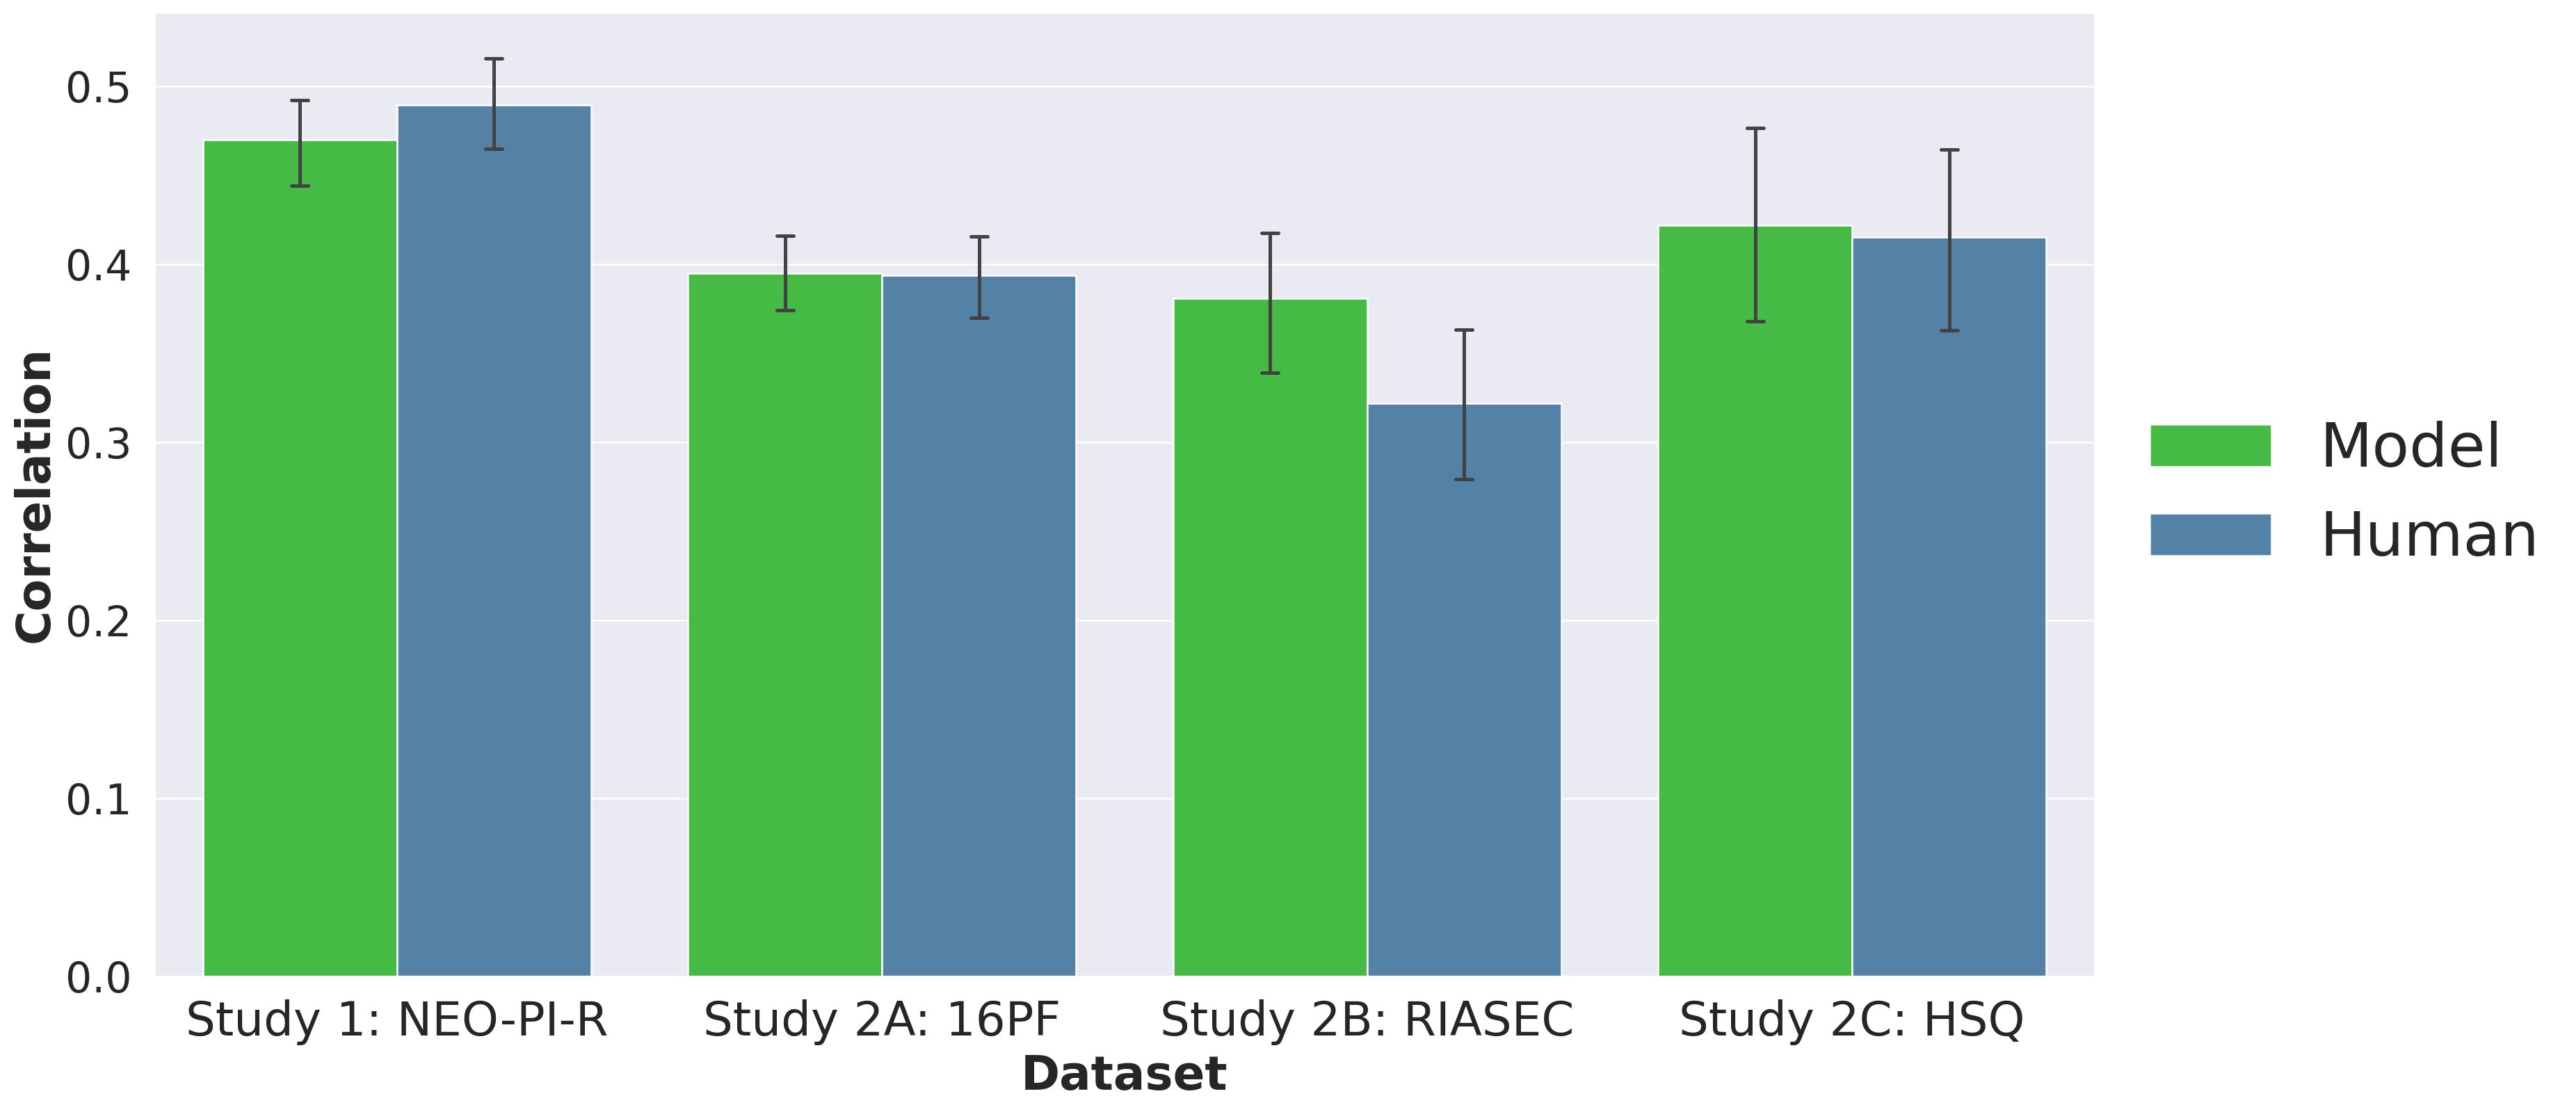

In [6]:
# prepare data: Add column to indicate the questionnaire/data -> combine all questionnaires into one dataset
df_comparisons_combined = pd.concat(df_comparisons, ignore_index=True)

#update font size, etc
plt.style.use("seaborn-v0_8")
sns.set_context('paper')
sns.set(font_scale = 1.4)

# Barplots: average performance across all targets (model vs human)
fig = plt.figure(figsize=(20, 10), dpi= 180)
sns.barplot(data=df_comparisons_combined, x="Dataset", y="Correlation", hue="Predictor", errorbar=('ci', 95), palette=["limegreen","steelblue"], capsize=0.07, err_kws={'linewidth': 2})
plt.ylabel("Correlation", fontweight='bold', fontsize=27)
plt.xlabel("Dataset", fontweight='bold', fontsize=27, labelpad=5)
plt.xticks(fontsize=27)
plt.yticks(fontsize=24)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize="35")    

#save figures
fig_name = "fig4.svg"
plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')
# fig_name = "fig4.tiff"
# plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')

Details (distribution and scatterplot)

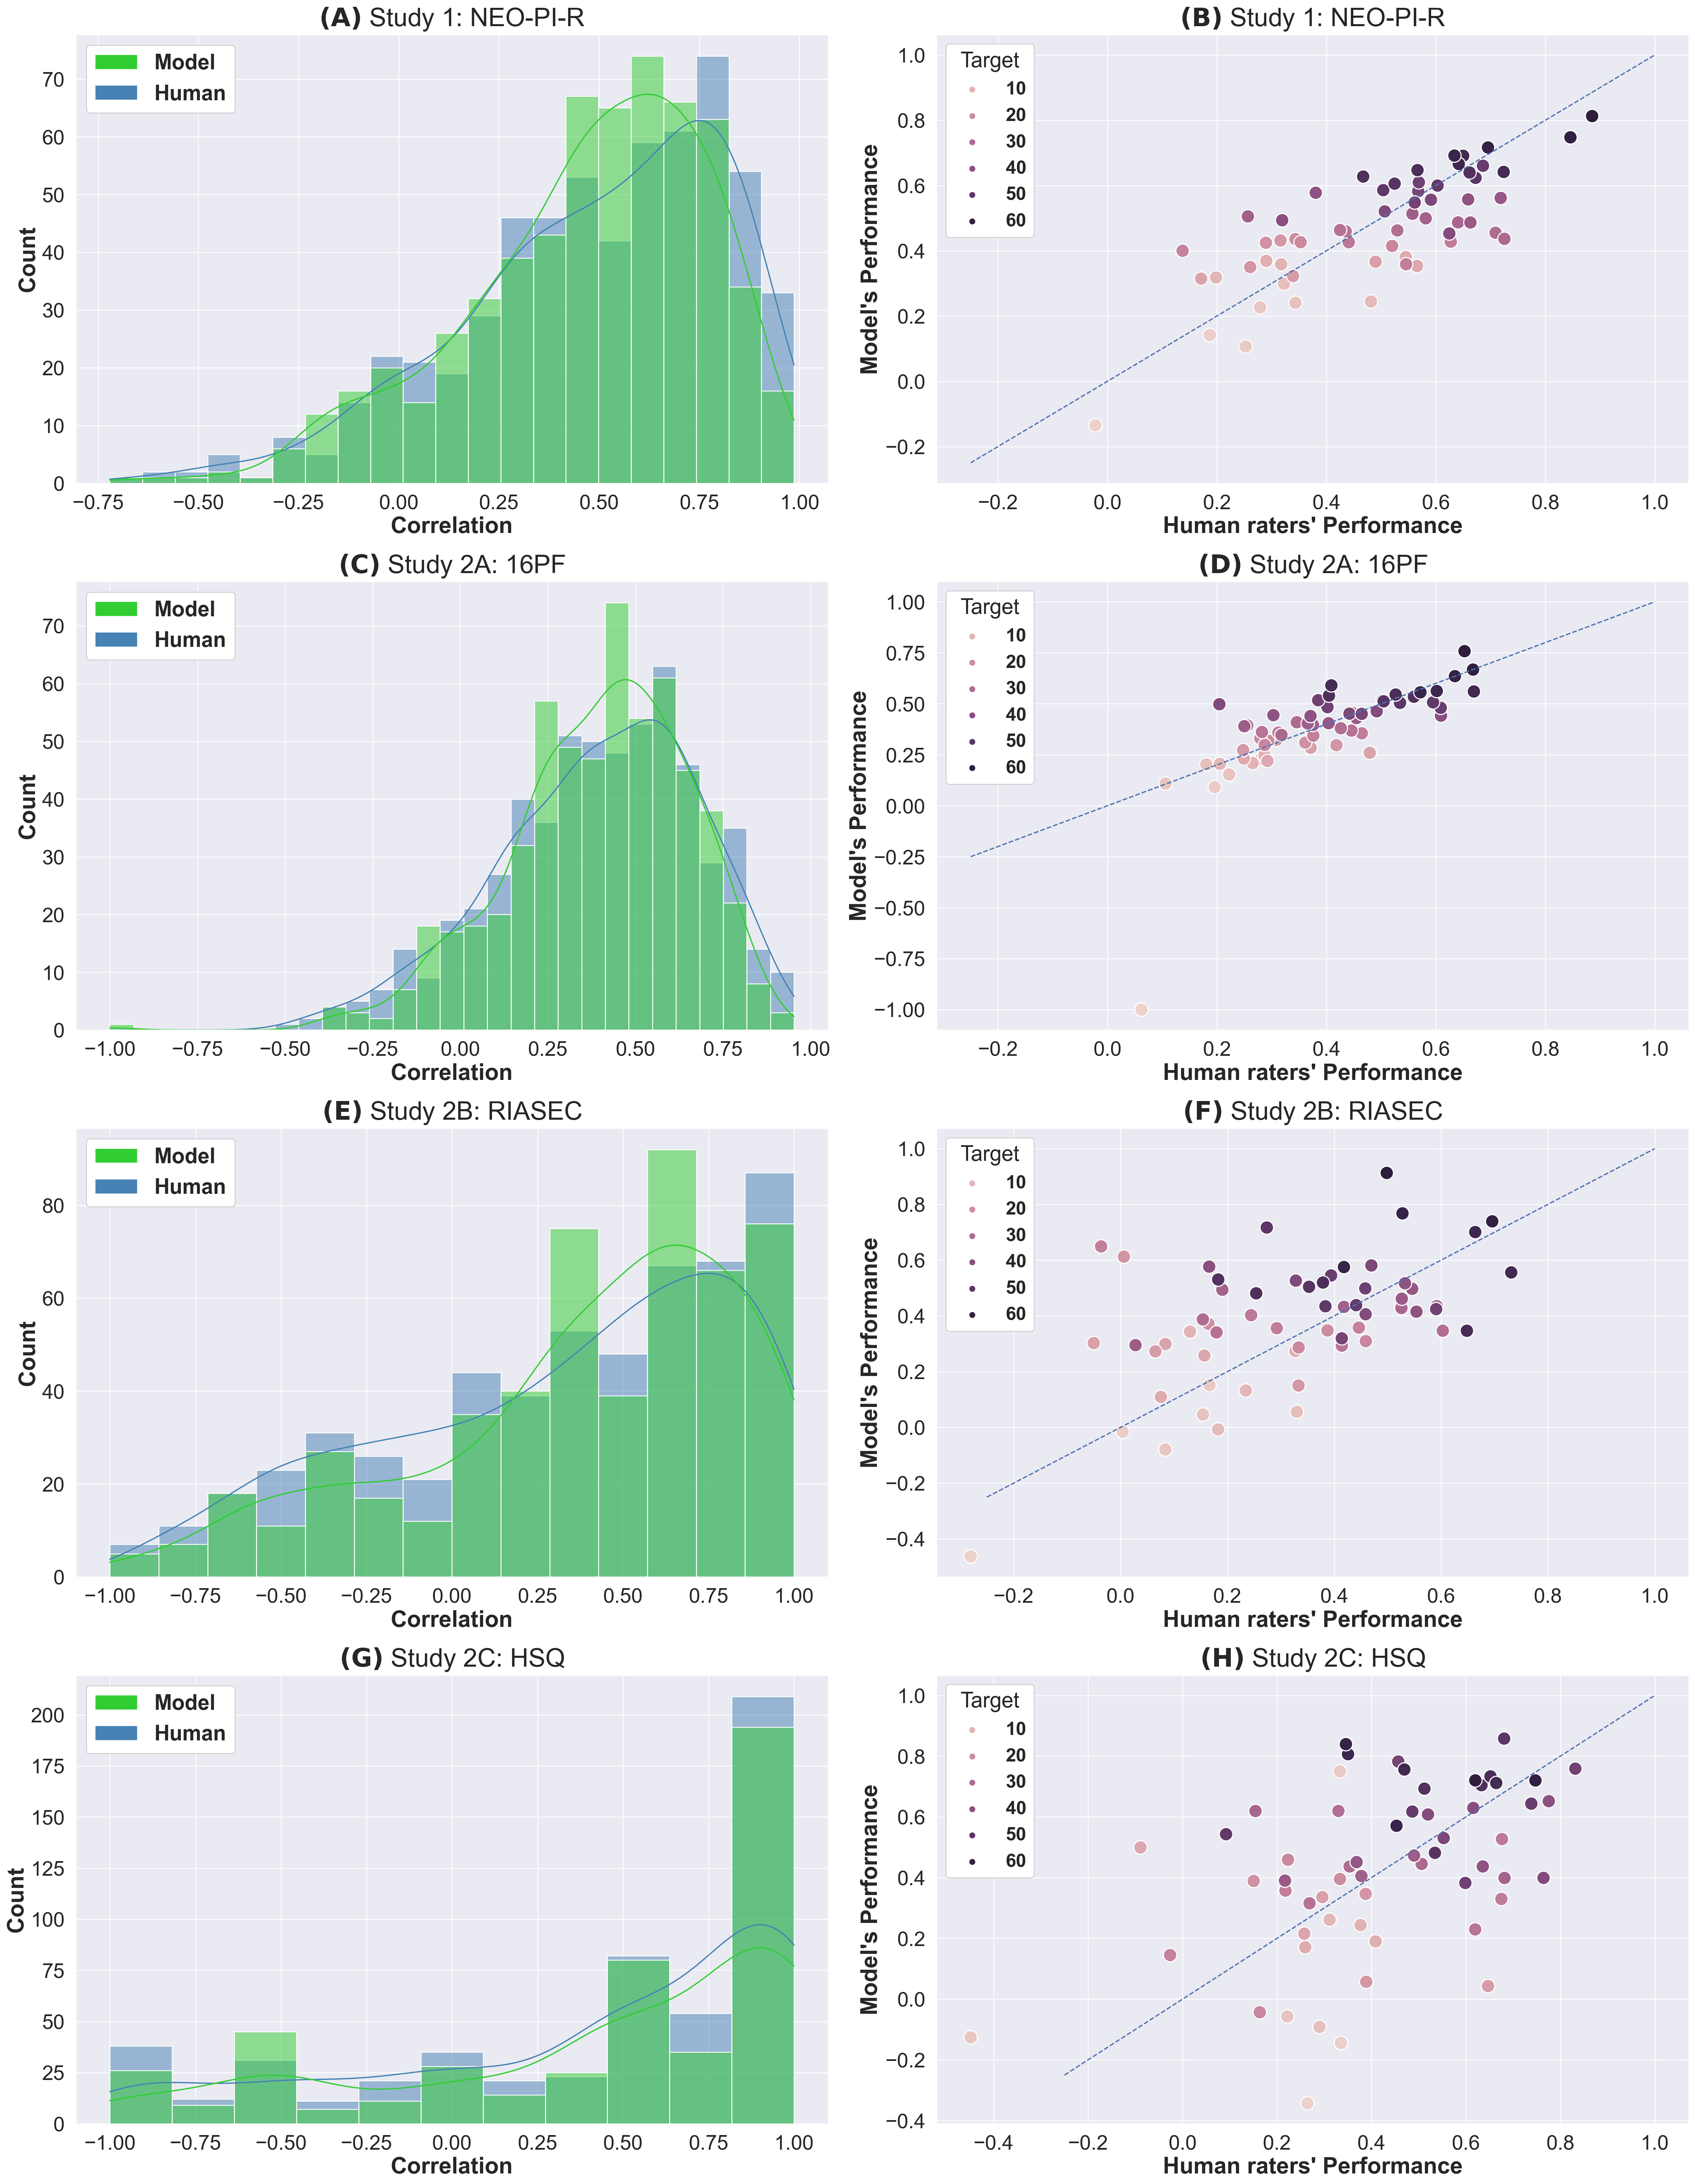

In [6]:
fig = plt.figure(figsize=(28, 36), dpi= 180)
fig.subplots_adjust(hspace=0.35, wspace=0.2)

palette=["limegreen","steelblue"]
handles = [Patch(facecolor=item) for item in palette]
alpha = list('abcdefghijklmnopqrstuvwxyz')

#update font size, etc
plt.style.use("seaborn-v0_8")
sns.set_context('paper')
sns.set(font_scale = 1.4)
    
for i, df_comparison in enumerate(df_comparisons): #creates figures starting after big5: numbering starts at fig_*_C

    #Add the distribution plots for each data set:
    ax = fig.add_subplot(4, 2, 2*(i)+1)
    sns.histplot(df_comparison, x="Correlation", kde=True, hue="Predictor", palette = palette, ax=ax)
    labels = df_comparison.Predictor.unique().tolist()
    ax.legend(loc = "upper left", handles = handles, labels = labels, frameon = True, framealpha = 1.0, facecolor='white',  prop={'weight':'bold', "size":25})
    ax.set_ylabel('Count', fontweight = "bold", fontsize = 27)
    ax.set_xlabel('Correlation', fontweight = "bold", fontsize = 27)
    plt.title(r"$\bf{(" + alpha[2*i].upper() + ")}$ " + df_comparison.Dataset[0], fontsize=30, pad=10)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)

    # Prepare data for scatter plots: Plot model average performance over human average performance on each target
    df = df_comparison.loc[:, ["target", "Predictor", "Correlation"]] .groupby(["target", "Predictor"], as_index=False).aggregate("mean")
    df_scatter = df.pivot(index="target", columns='Predictor', values='Correlation').rename_axis(None, axis=1).reset_index()

    # Scatter plots
    ax = fig.add_subplot(4, 2, 2*(i)+2)
    sns.scatterplot(data=df_scatter, x="Human", y="Model", hue="target", s=250, alpha=1.0, ax=ax)
    ax.set_ylabel('Model\'s Performance', fontweight = "bold", fontsize=27)
    ax.set_xlabel('Human raters\' Performance', fontweight = "bold", fontsize=27)
    ax.legend(loc="upper left", frameon = True, framealpha = 1.0, facecolor='white', prop={'weight':'bold','size':22}, title="Target", title_fontsize=25)
    ax.plot((-0.25, 1),(-0.25, 1), ls='--')
    plt.title(r"$\bf{(" + alpha[2*i+1].upper() + ")}$ " + df_comparison.Dataset[0], fontsize=30, pad=10)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    
#save figures
fig_name = "fig5.pdf" #update figure name 
plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')
# fig_name = "fig5.tiff" #update figure name 
# plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Check outliers

In [7]:
ds =  "Study 2C: HSQ"
data = df_comparisons_combined.loc[(df_comparisons_combined.Dataset == ds) & (df_comparisons_combined.Predictor == "Model"), "Correlation"].values

a = 1.0 * data
a = a[~np.isnan(a)] #remove nan
n = len(a)
m, se = np.mean(a, 0), stats.sem(a)
h = se * stats.t.ppf((1 + .95) / 2., n-1)

print([m, m-h, m+h])

data = df_comparisons_combined.loc[(df_comparisons_combined.Dataset == ds) & (df_comparisons_combined.Predictor == "Human"), "Correlation"].values

a = 1.0 * data
a = a[~np.isnan(a)] #remove nan
n = len(a)
m, se = np.mean(a, 0), stats.sem(a)
h = se * stats.t.ppf((1 + .95) / 2., n-1)

print([m, m-h, m+h])

[0.4221848608998206, 0.3679614513330343, 0.4764082704666069]
[0.41527663000282544, 0.3638342787012902, 0.4667189813043607]


## Single plots

### Bar and distribution plots

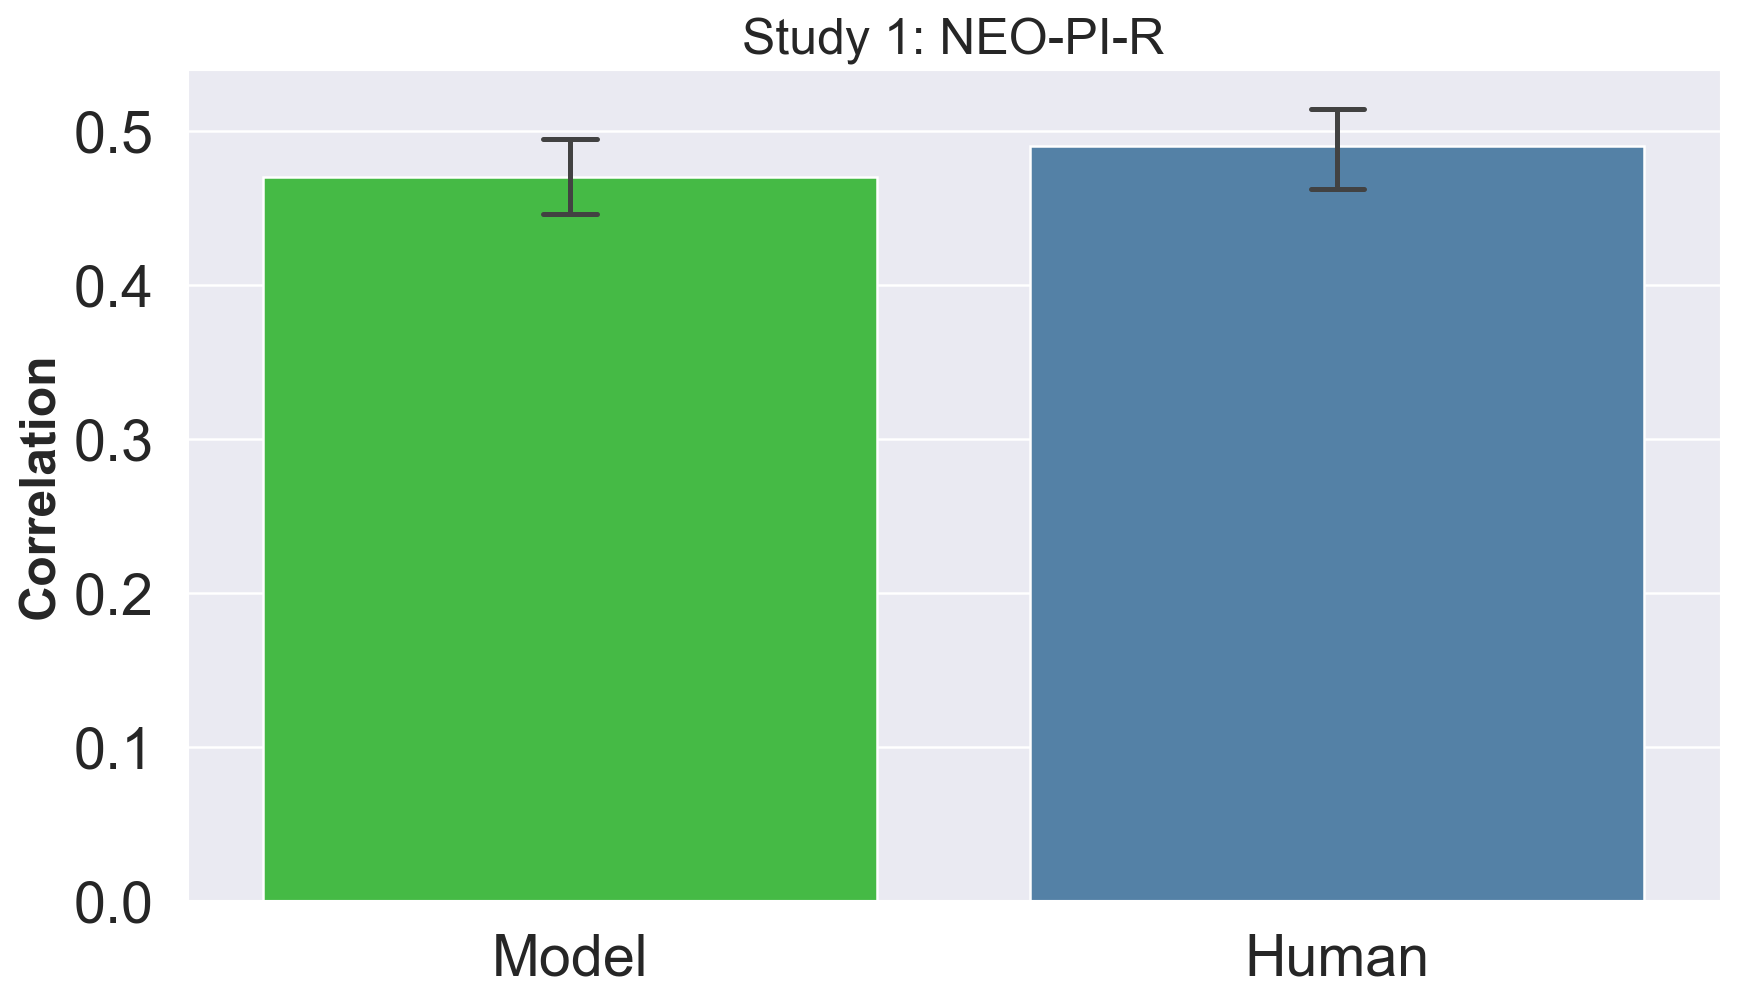

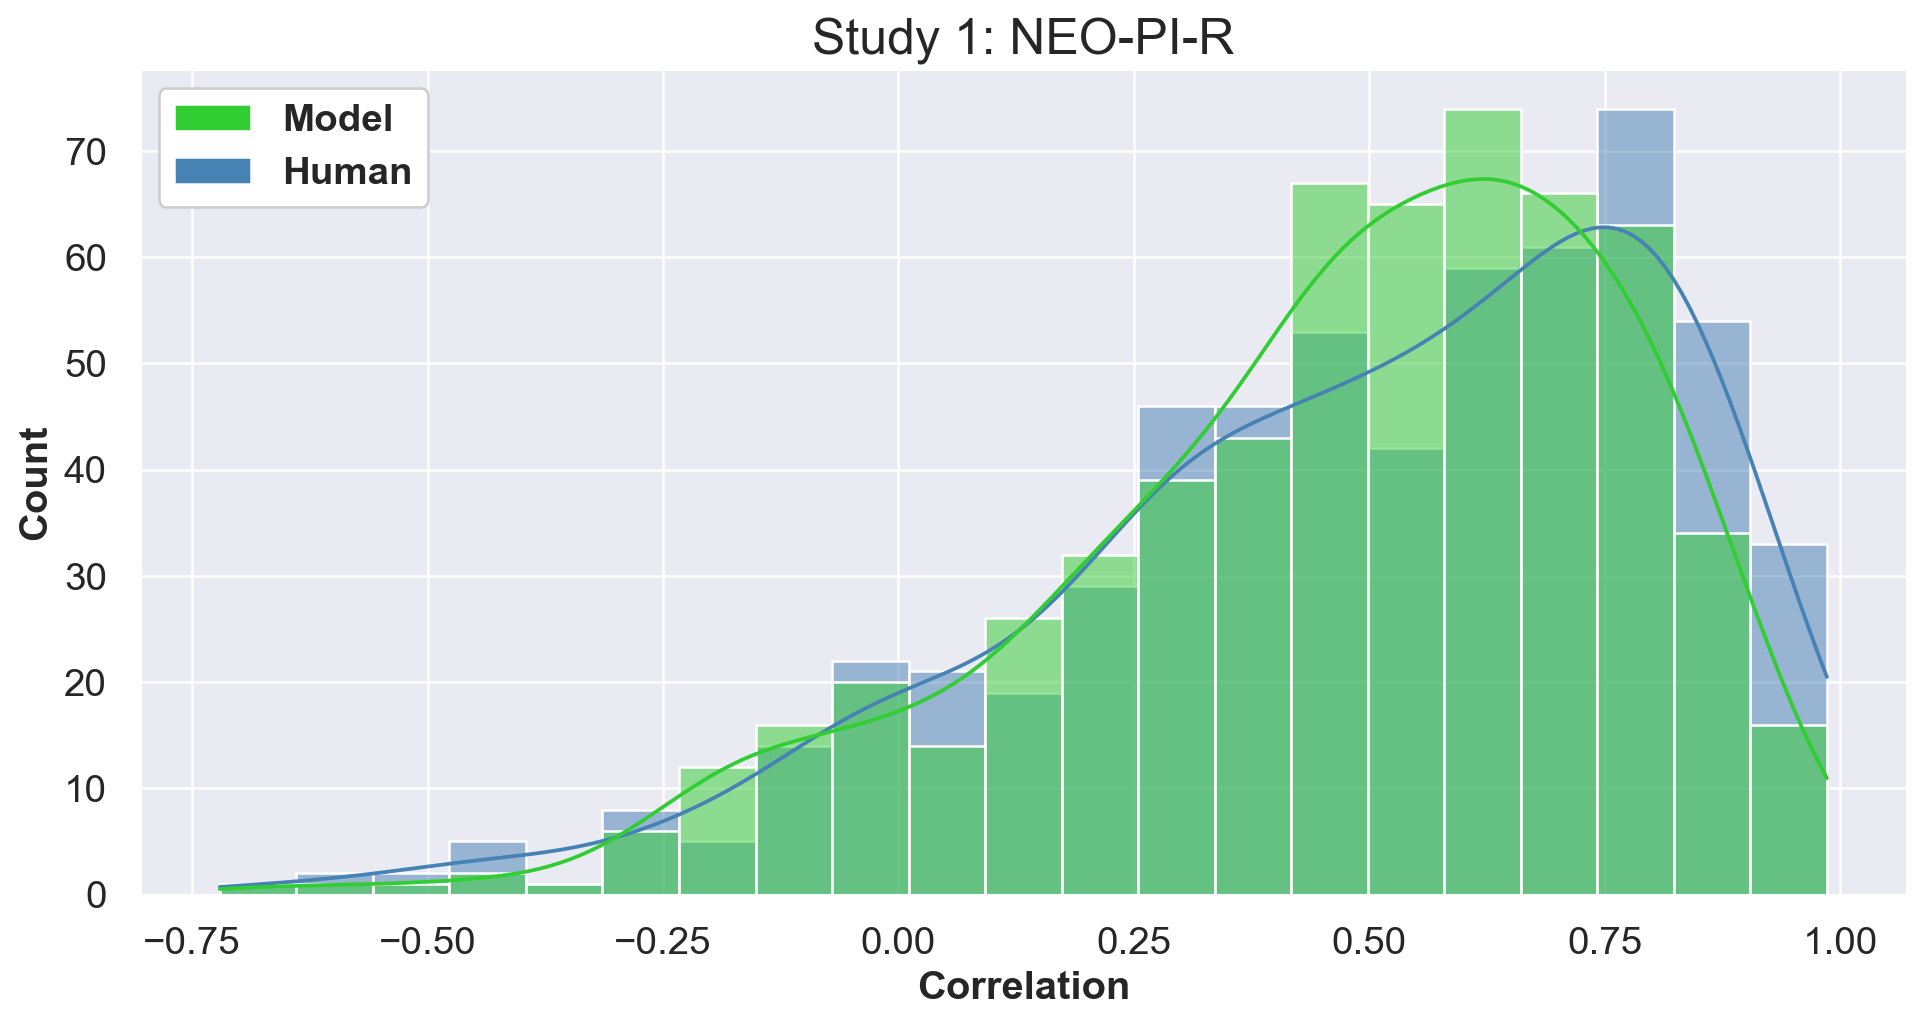

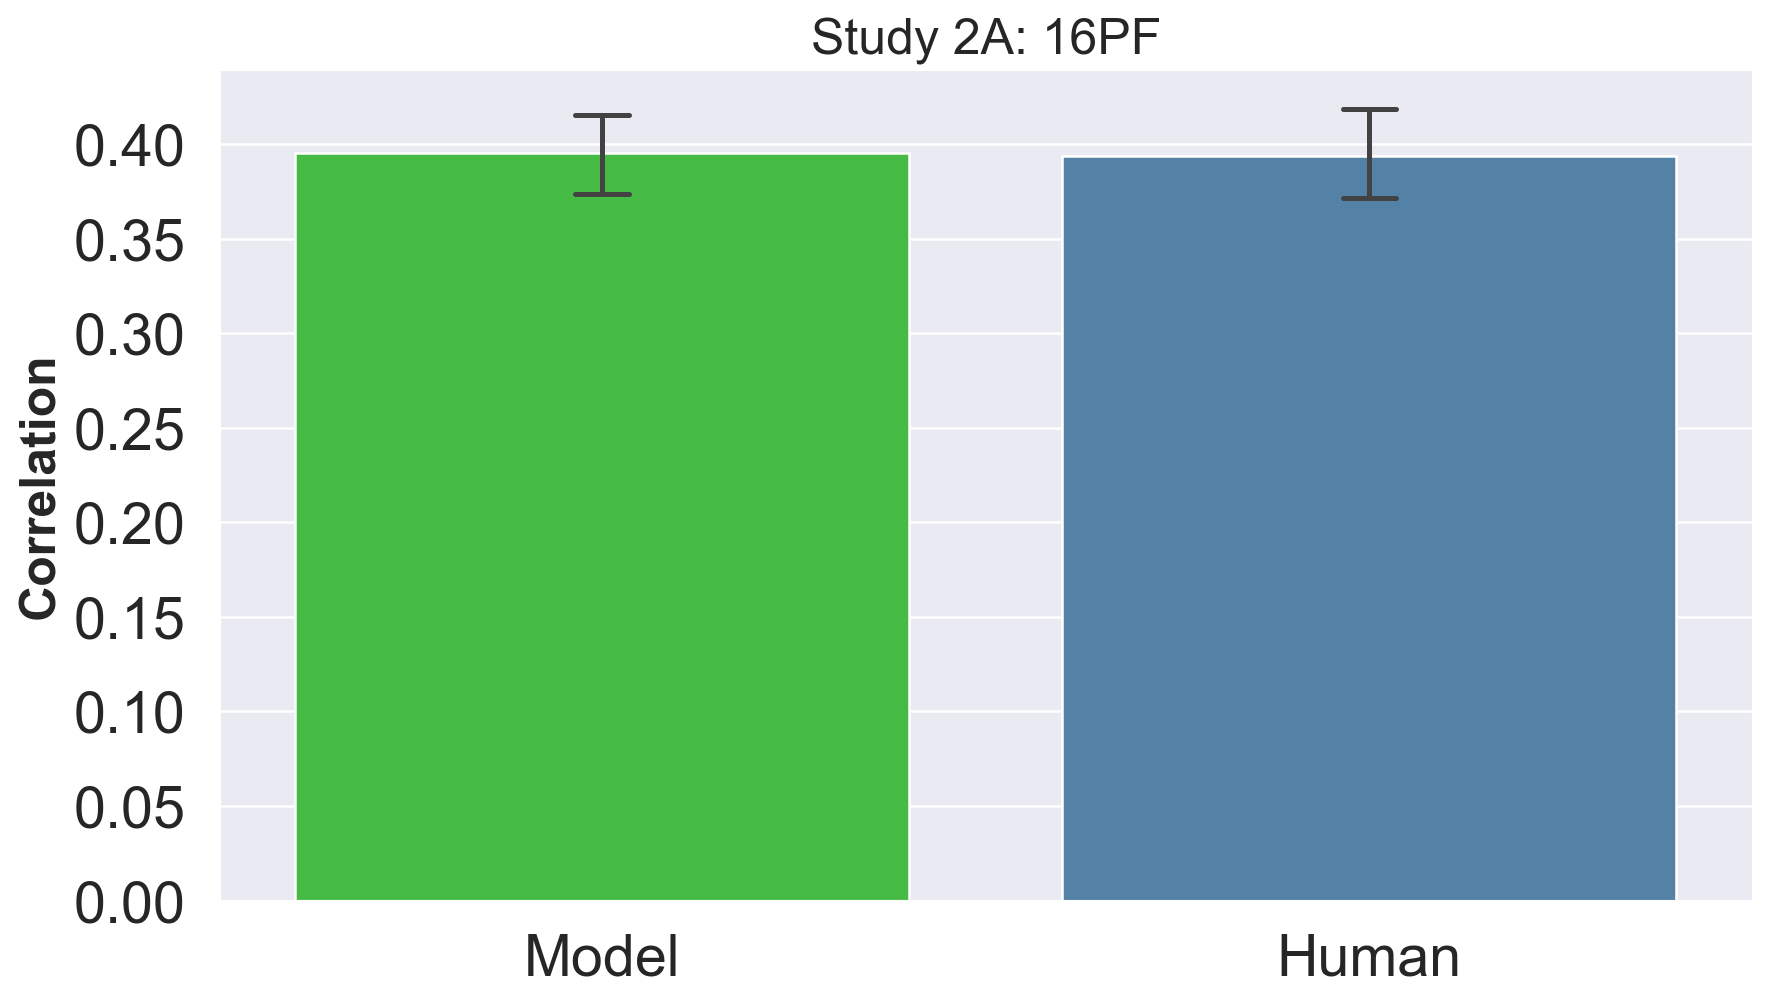

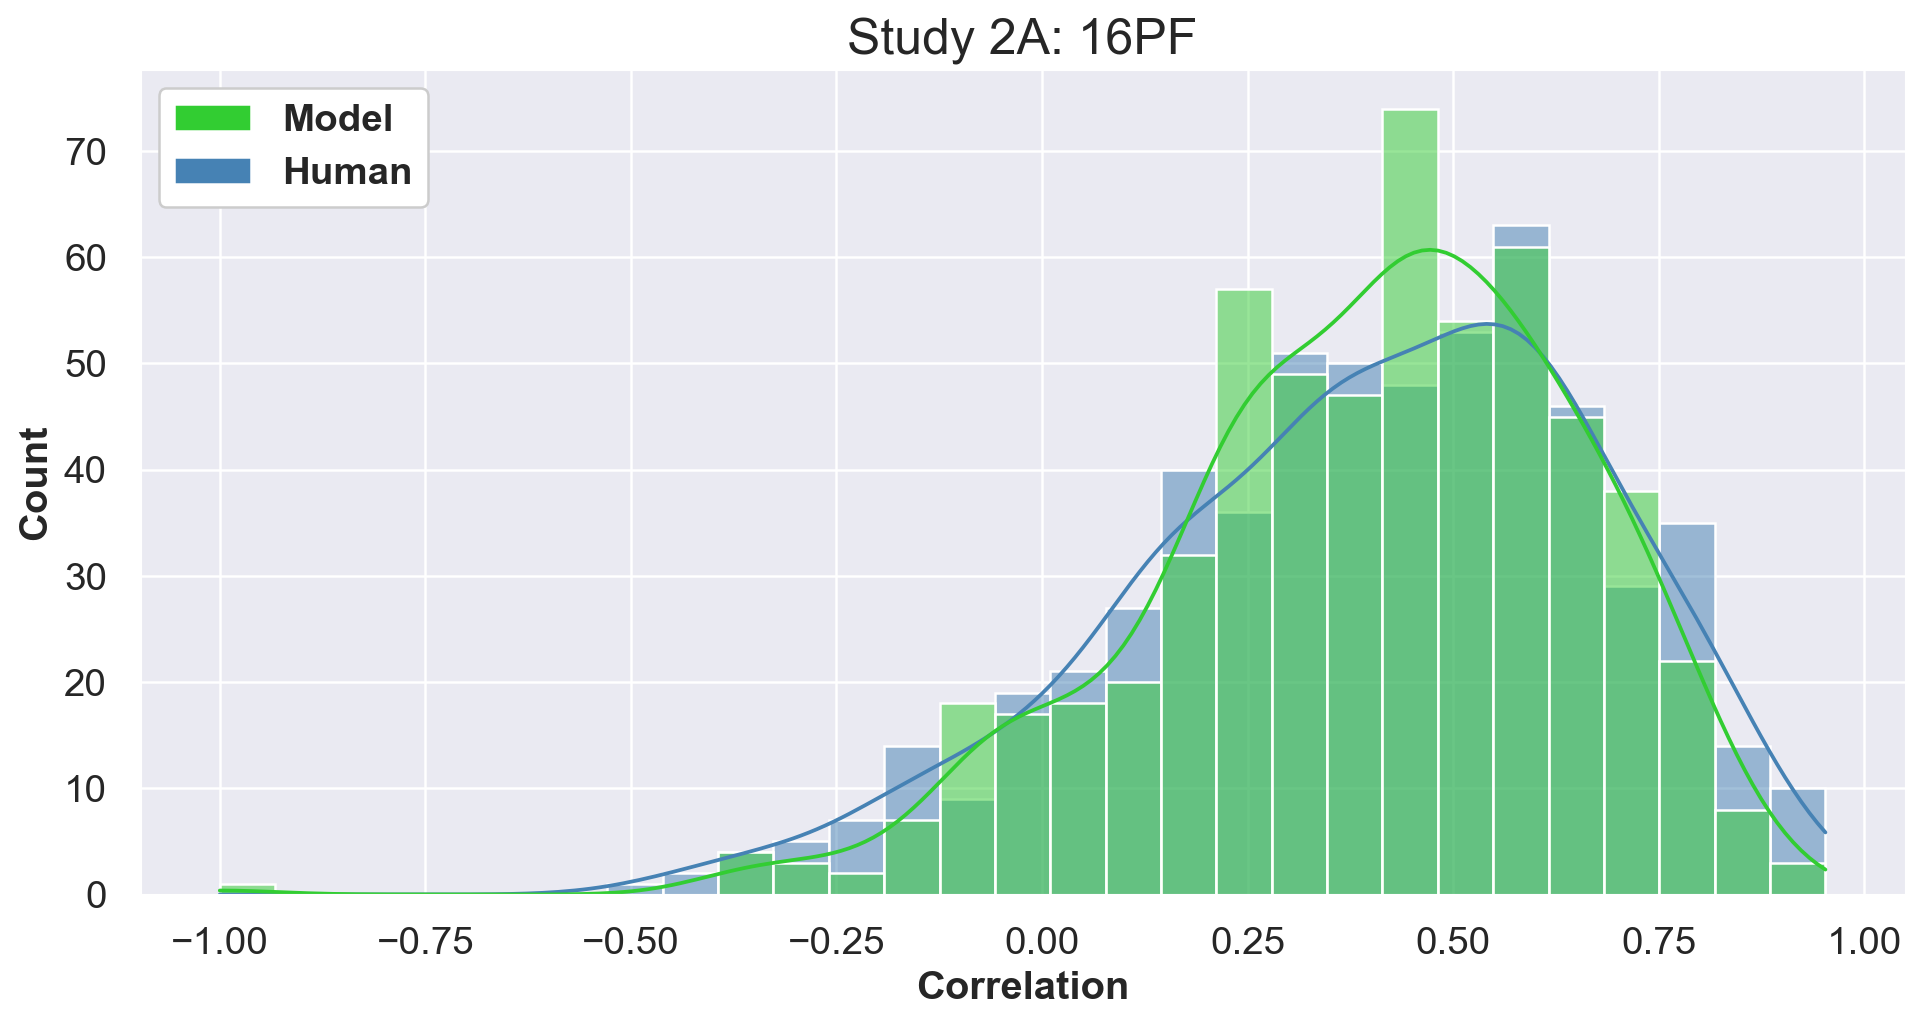

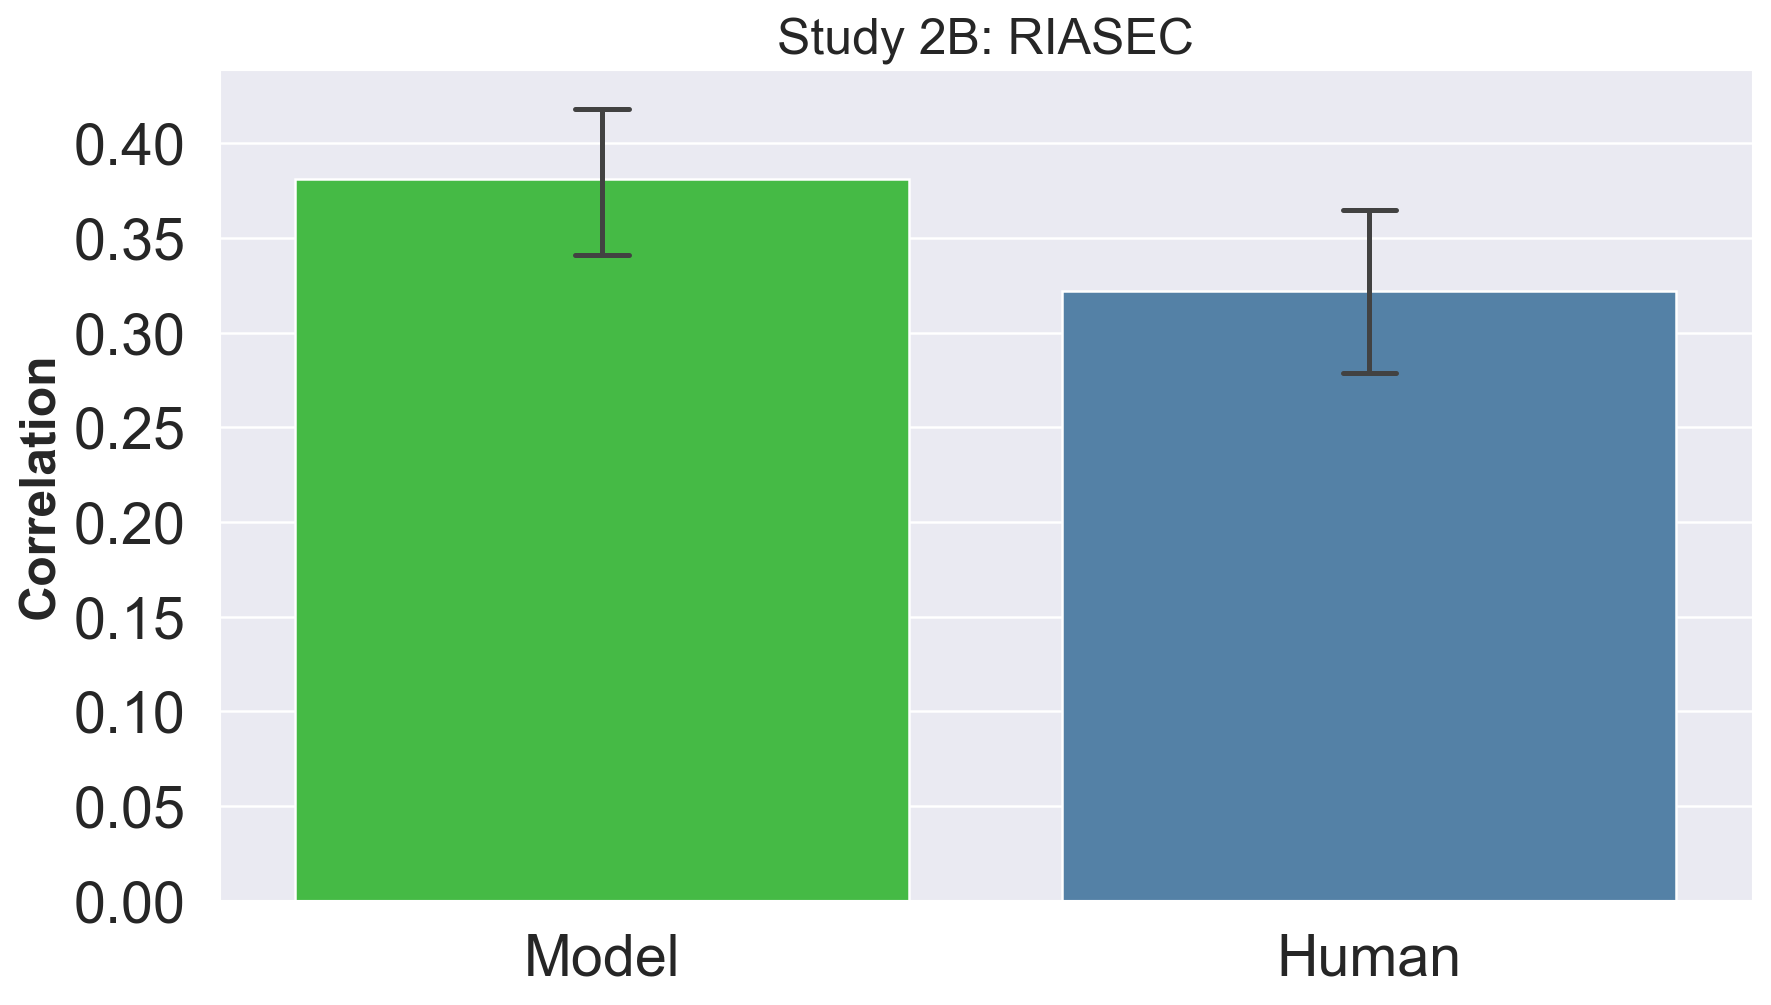

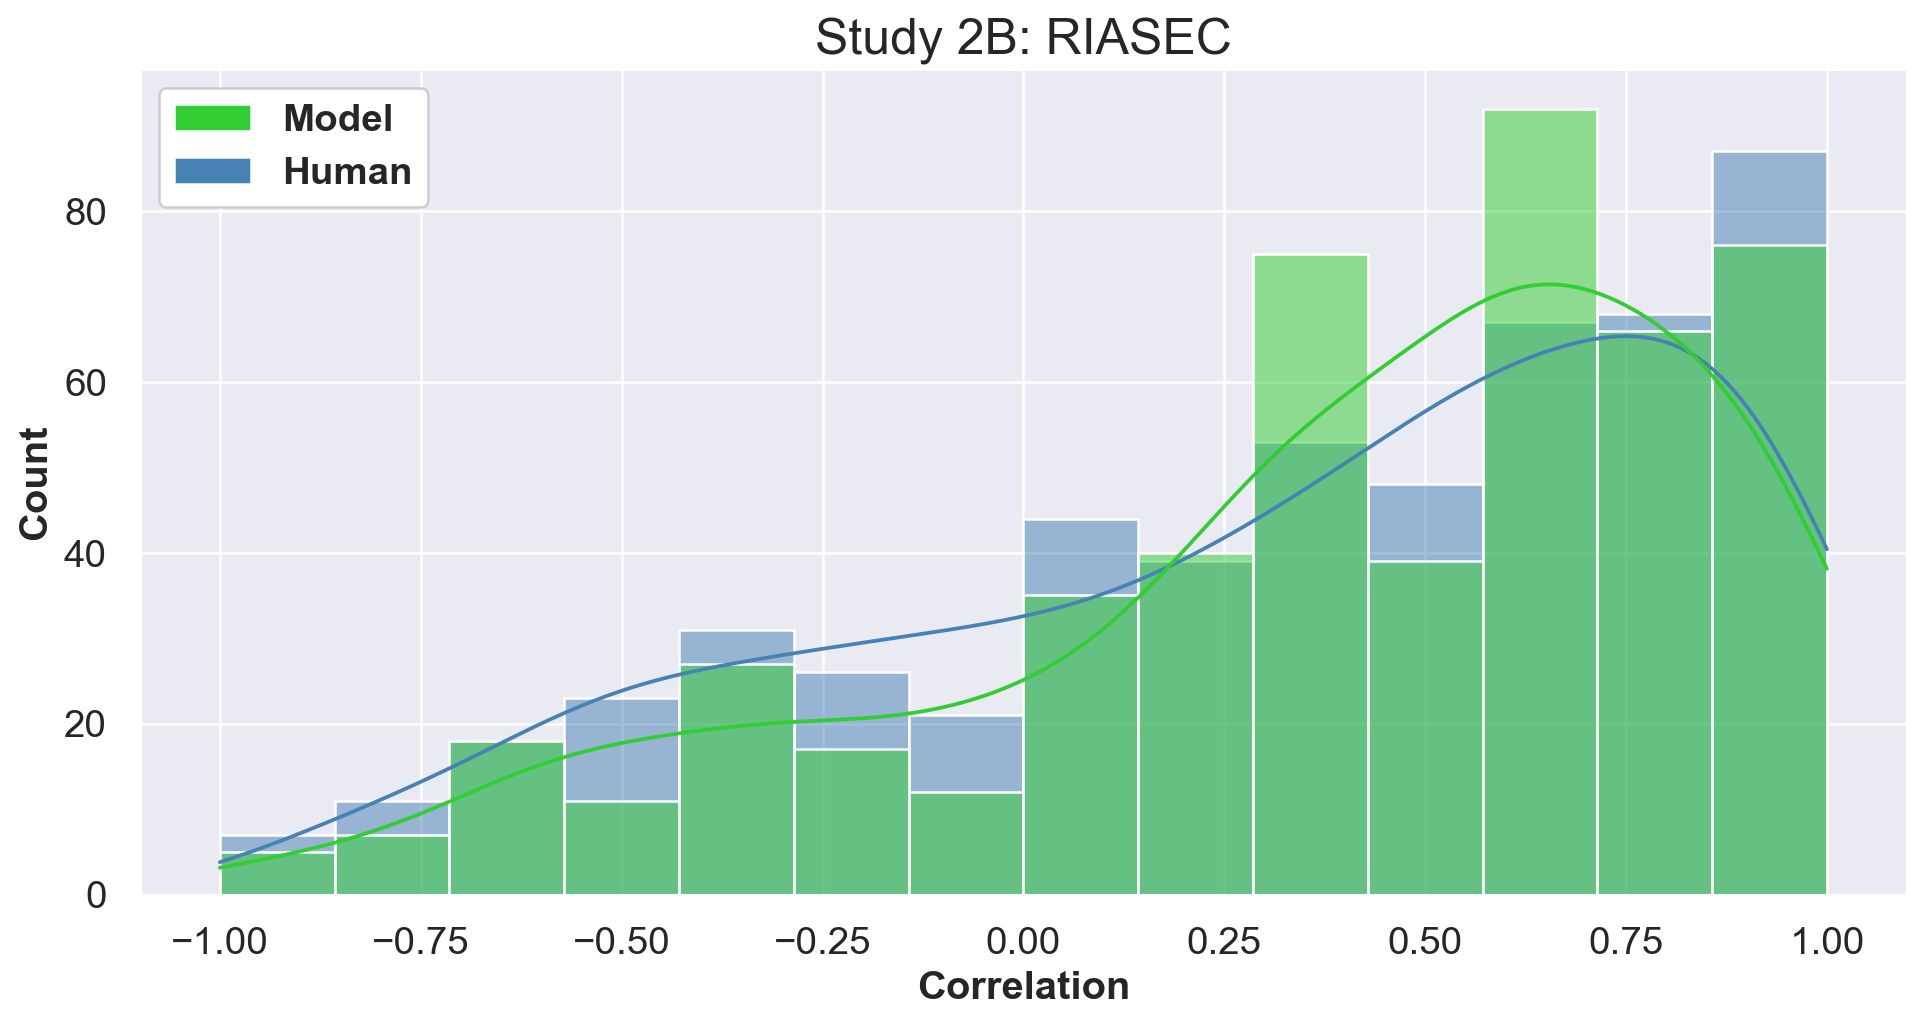

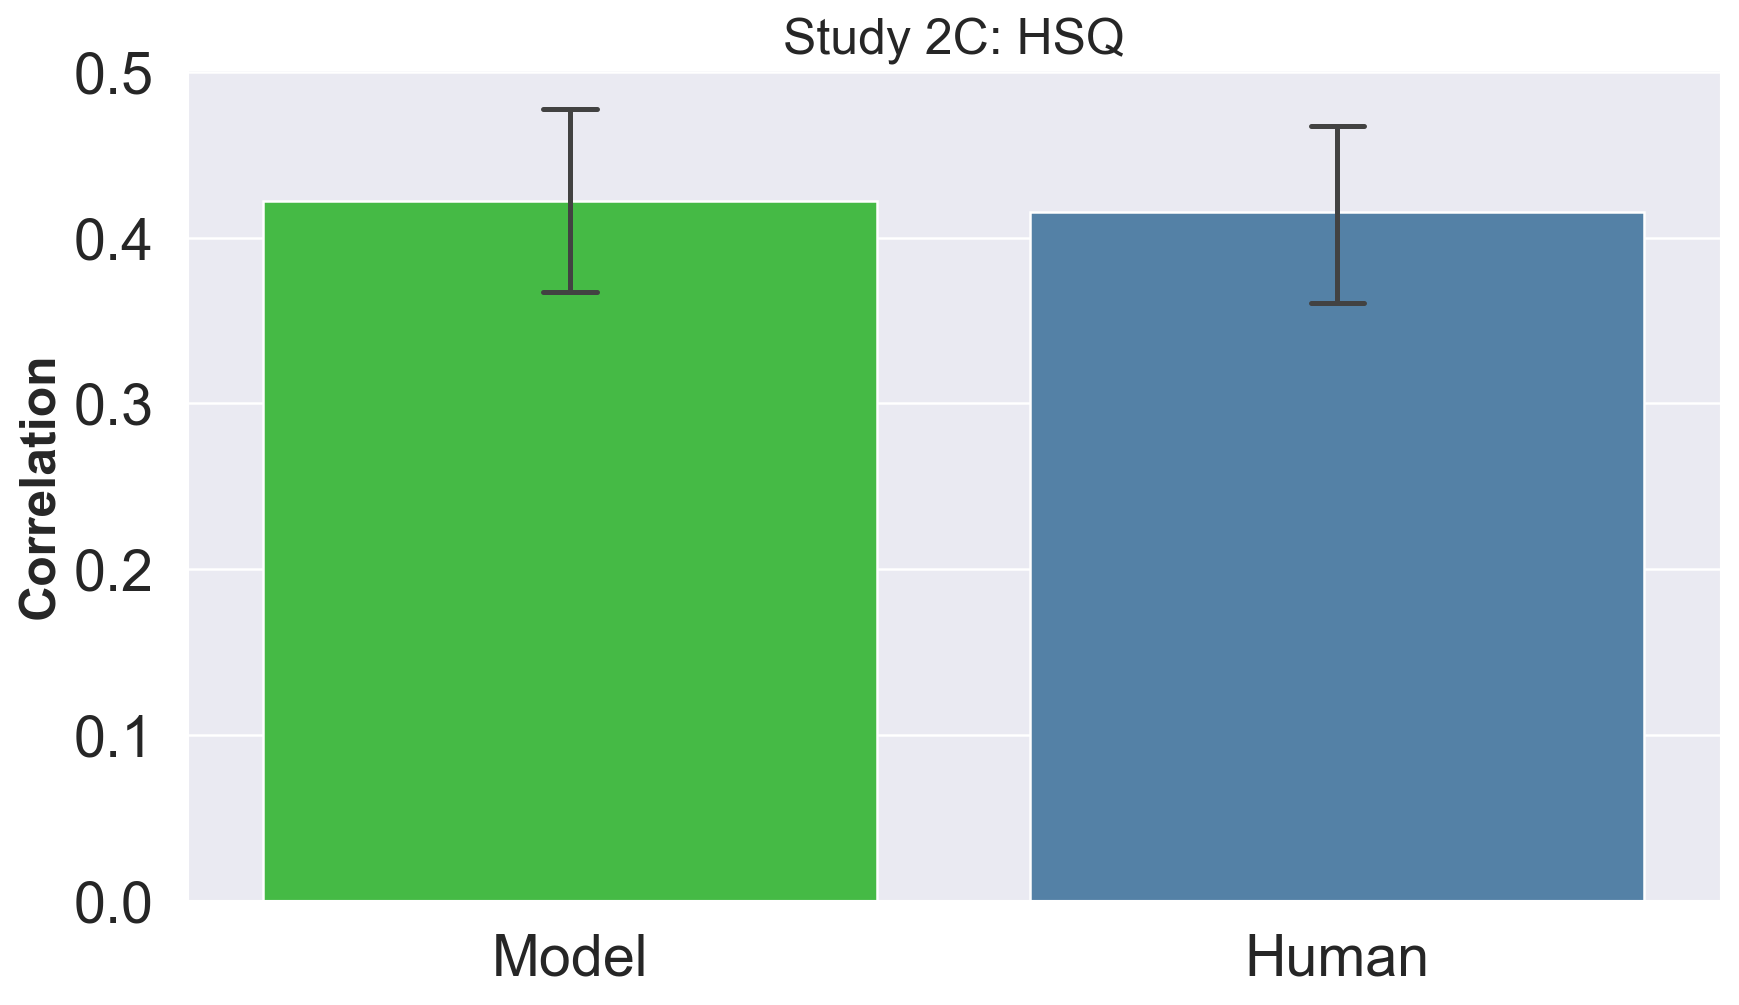

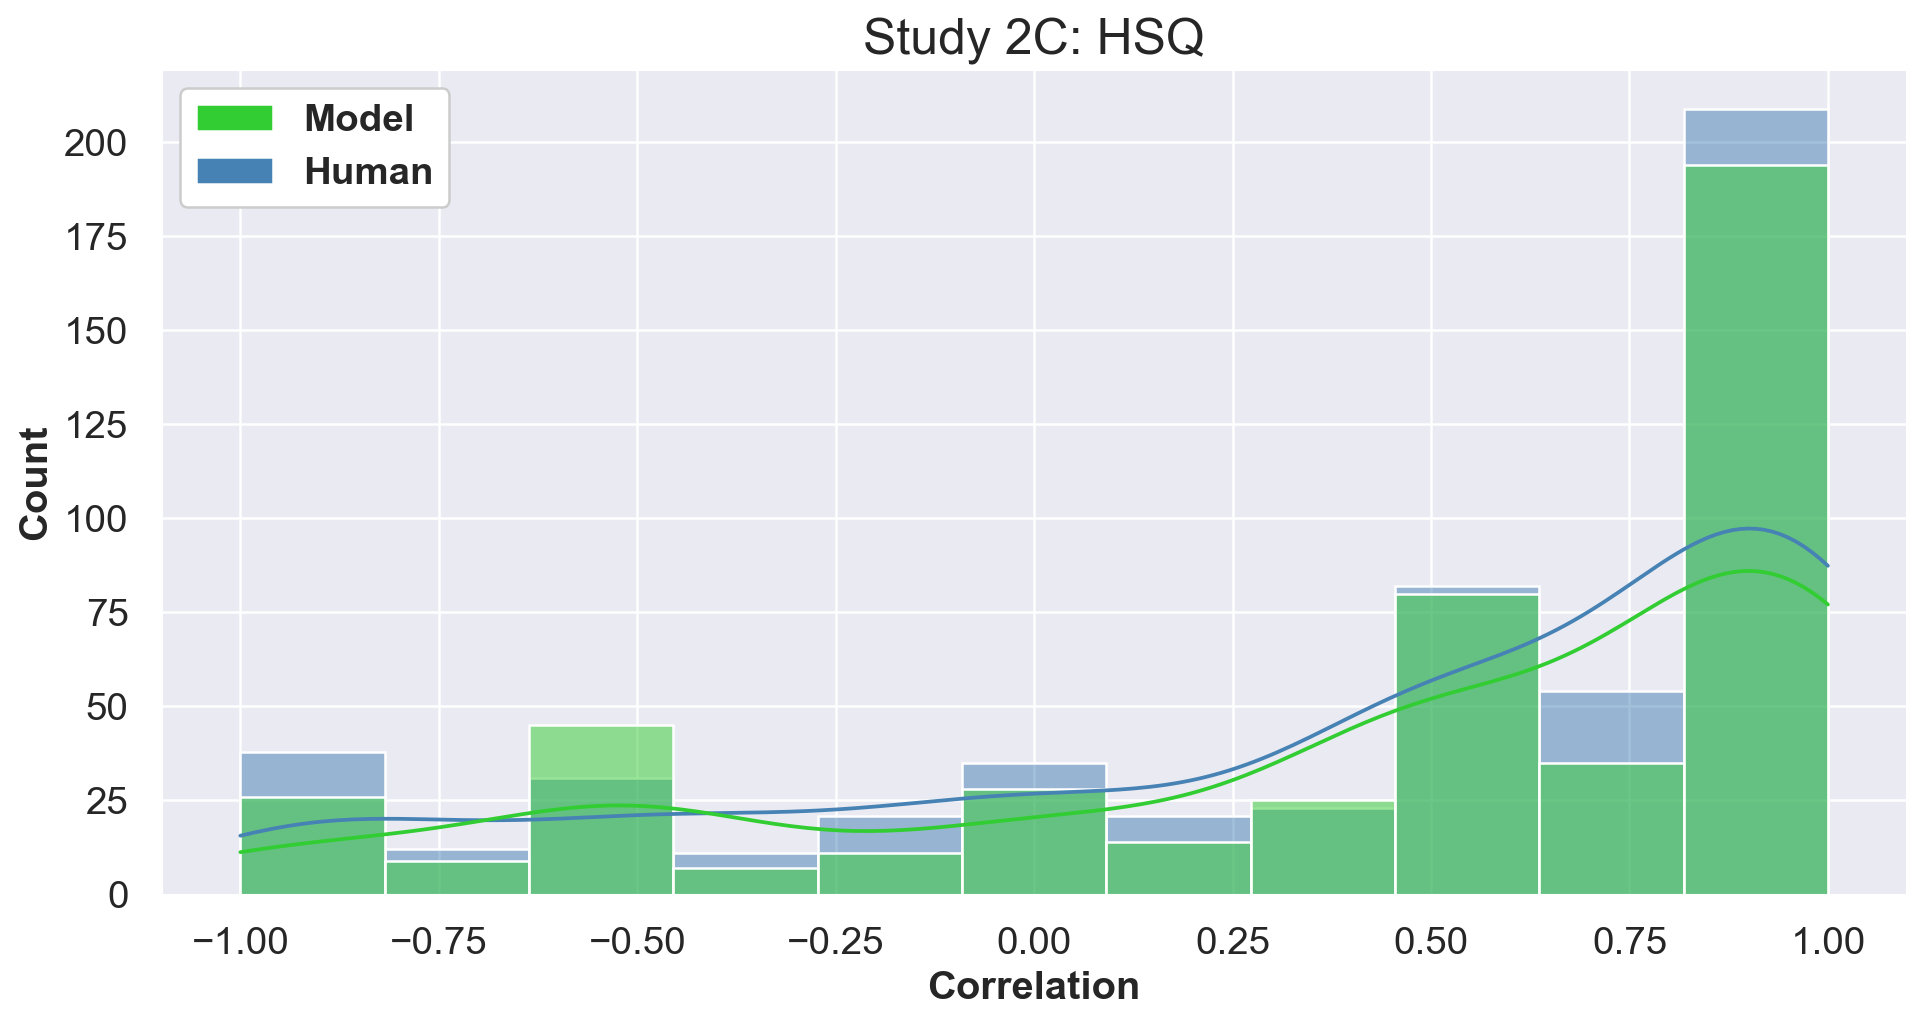

In [8]:
for i, df_comparison in enumerate(df_comparisons): #creates figures starting after big5: numbering starts at fig_*_C
    
    #update font size, etc
    # create barplots (comparing average performances)
    plt.style.use("seaborn-v0_8")
    sns.set_context('paper')
    sns.set(font_scale = 1.4)

    fig  = plt.figure(figsize=(11, 6), dpi= 180)
    ax = sns.barplot(y='Correlation', x='Predictor', orient='v', data=df_comparison, errorbar=('ci', 95), 
                         palette=["limegreen","steelblue"], capsize=0.07, err_kws={'linewidth': 2})
    plt.ylabel("Correlation", fontweight='bold', fontsize=20)
    plt.xlabel("", fontweight='bold', fontsize=20, labelpad=-13)
    plt.xticks(fontsize=23)
    plt.yticks(fontsize=23)
    plt.title(df_comparison.Dataset[0], fontsize=20)

    fig_name = "fig4_" + chr(65+i) + ".pdf"
    plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')

    #Add the distribution plots for each questionnaire:
    fig  = plt.figure(figsize=(11, 6), dpi= 180)
    palette=["limegreen","steelblue"]
    ax = sns.histplot(df_comparison, x="Correlation", kde=True, hue="Predictor", palette = palette)
    handles = [Patch(facecolor=item) for item in palette]
    labels = df_comparison.Predictor.unique().tolist()
    ax.legend(loc = "upper left", handles = handles, labels = labels, frameon = True, framealpha = 1.0, facecolor='white', prop={'weight':'bold'})
    ax.set_ylabel('Count', fontweight = "bold", fontsize = 16)
    ax.set_xlabel('Correlation', fontweight = "bold", fontsize = 16)
    plt.title(df_comparison.Dataset[0], fontsize=20)

    #save figures
    fig_name = "fig5_" + chr(65+2*i) + ".pdf" #update figure name (to skip 3rd number)
    plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')

    plt.tight_layout()
    plt.subplots_adjust(hspace = 1)
    plt.show()        

### Scatterplots

PearsonRResult(statistic=0.7600474795947542, pvalue=1.88890405443892e-12)
PearsonRResult(statistic=0.6992821594860221, pvalue=7.247033378583878e-10)
PearsonRResult(statistic=0.5307219726756942, pvalue=1.2885182568260498e-05)
PearsonRResult(statistic=0.4642035727447916, pvalue=0.00021275446095890495)


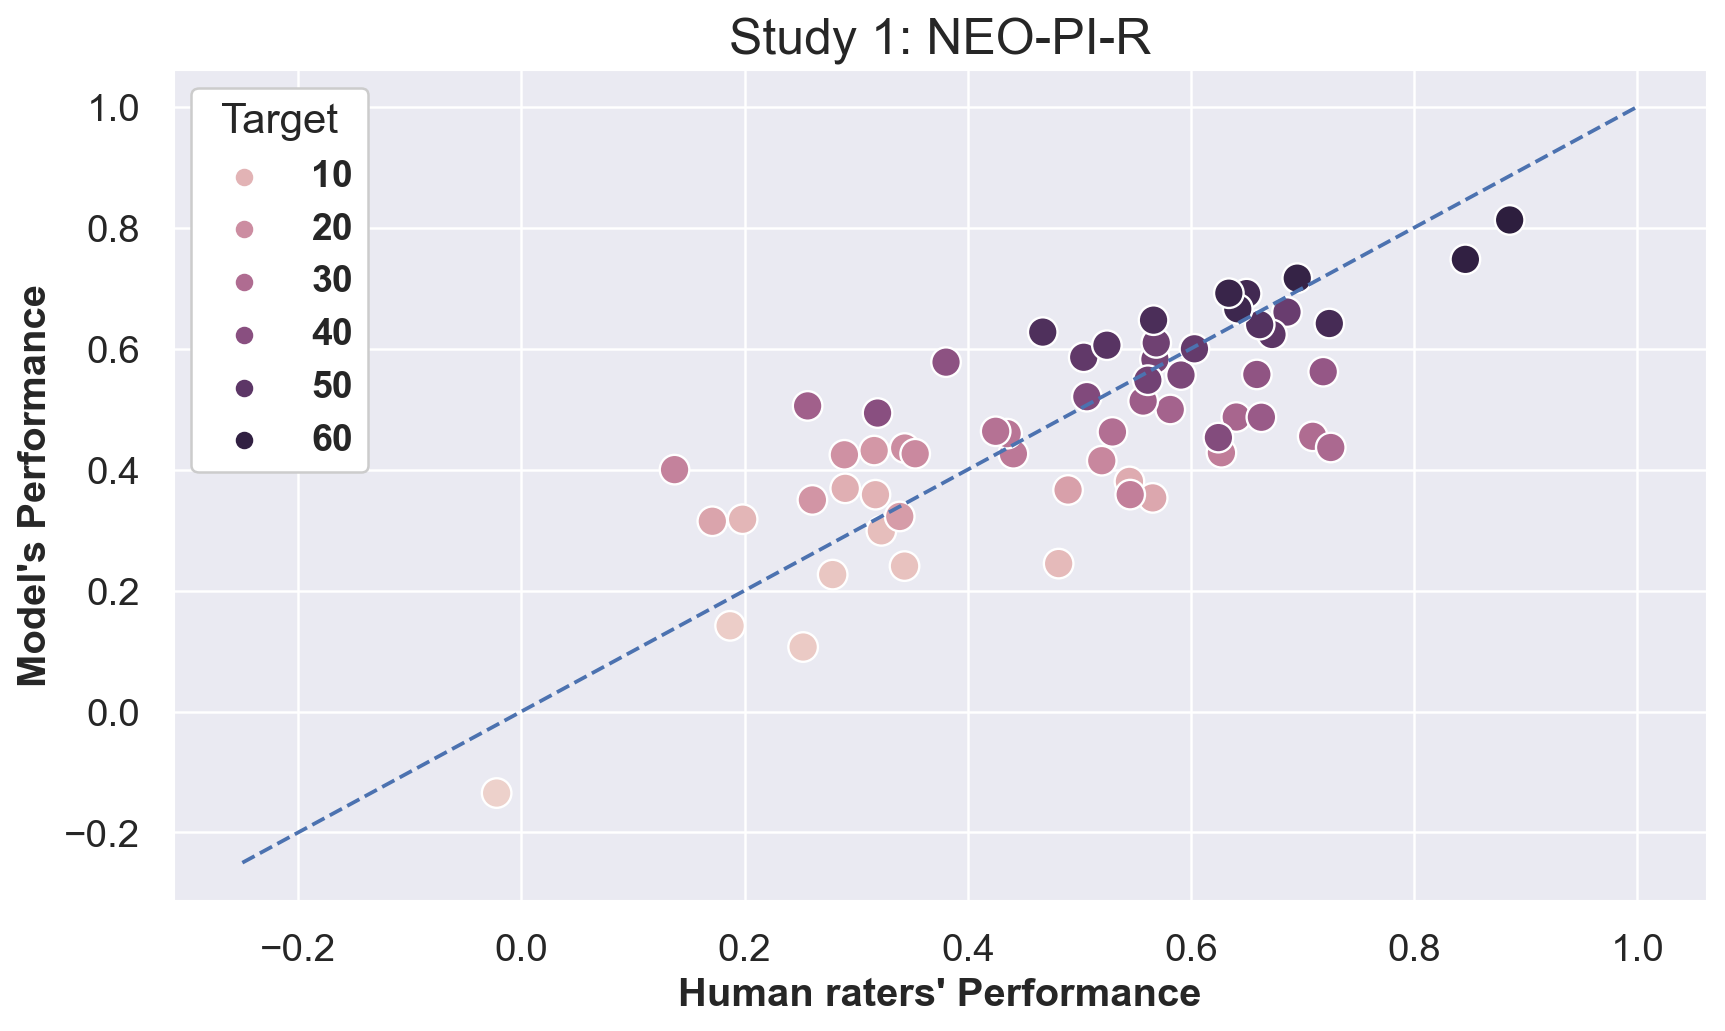

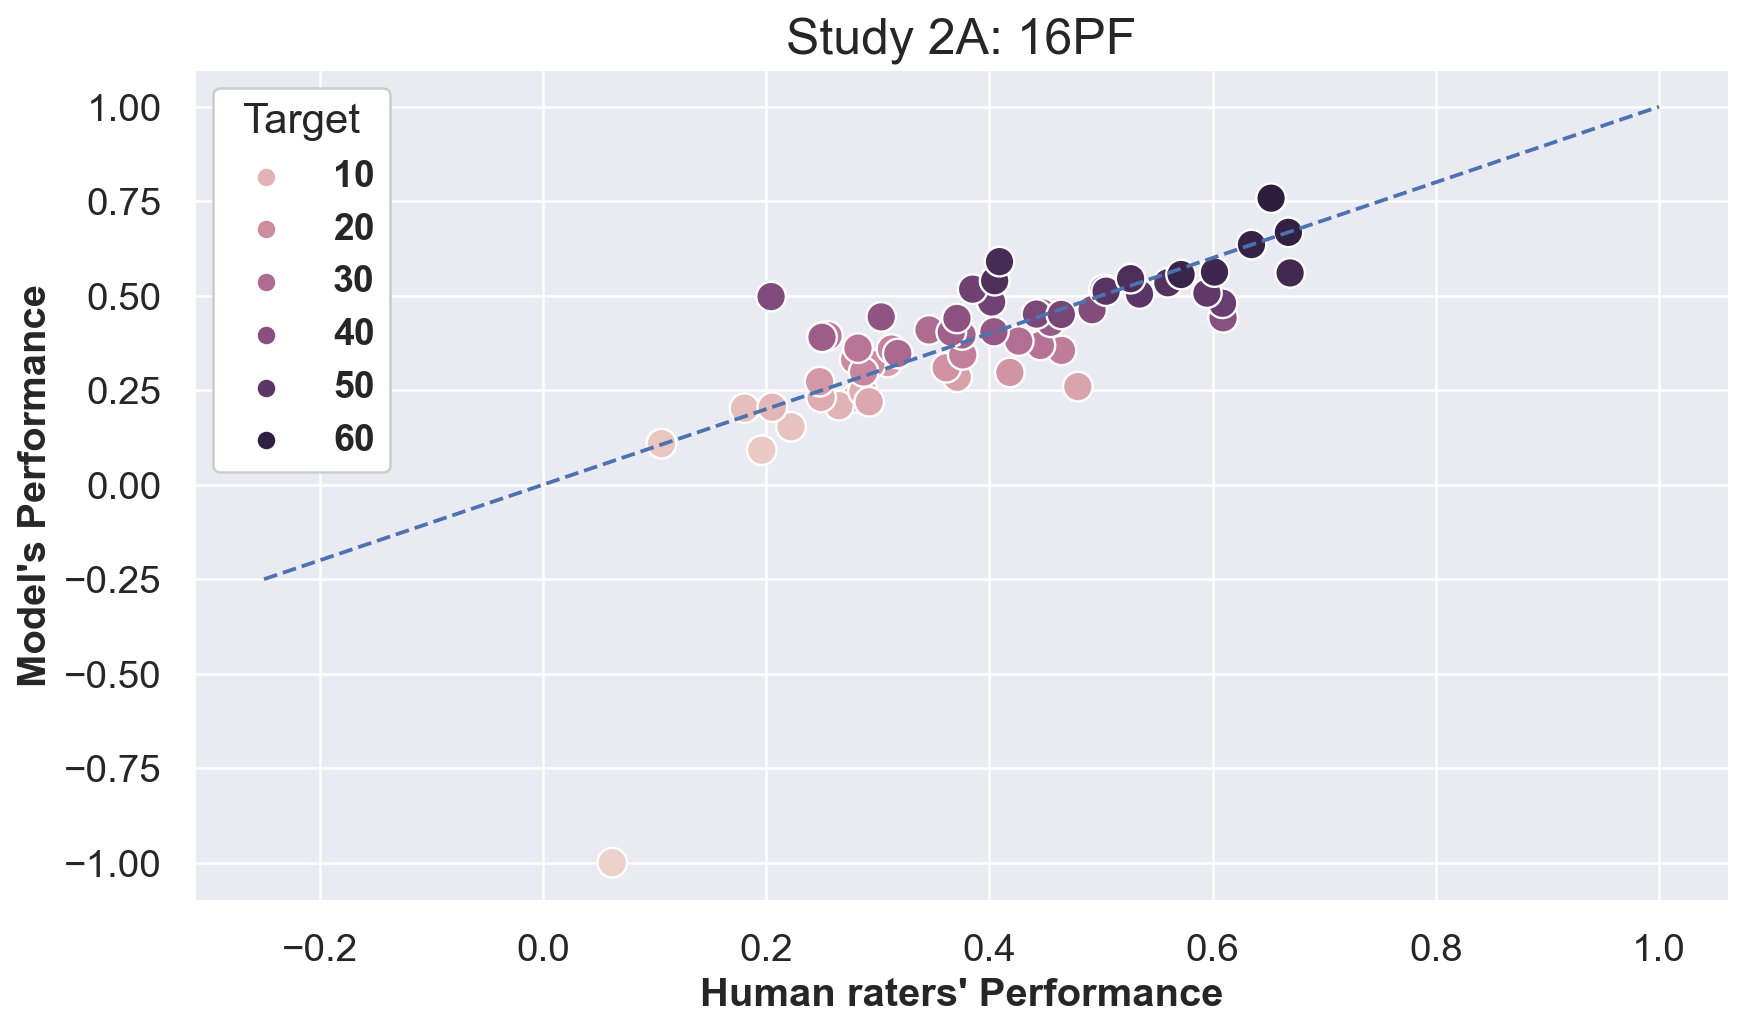

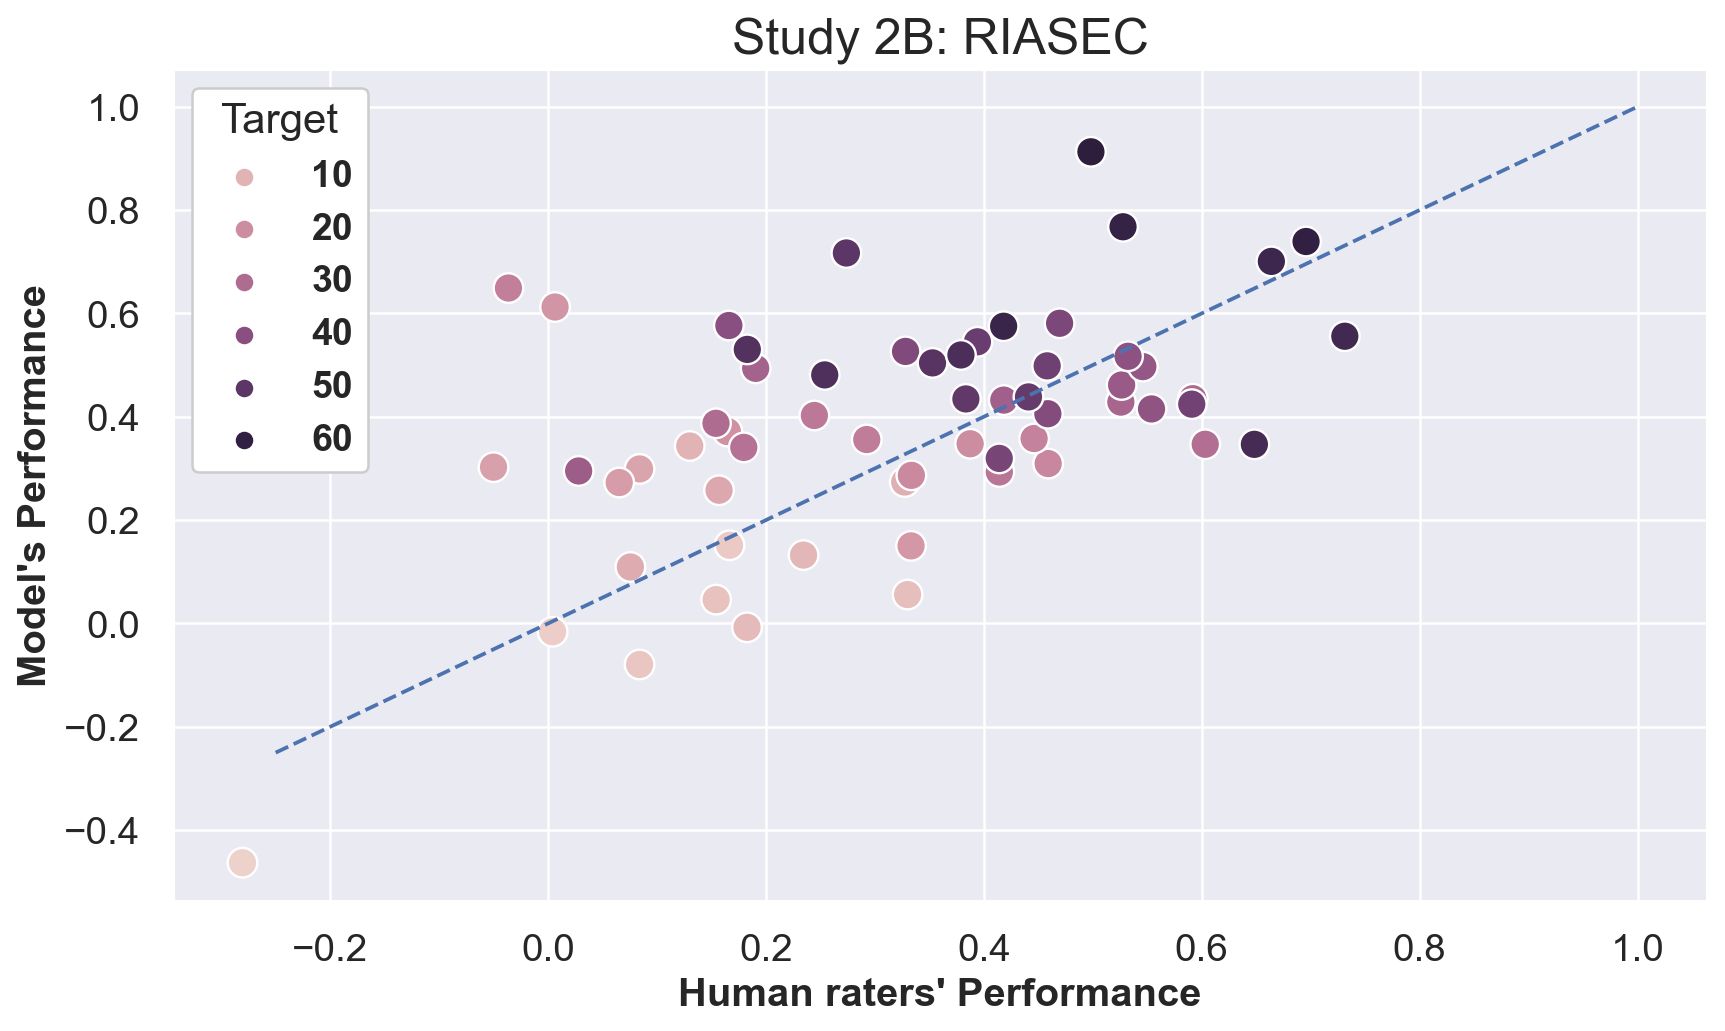

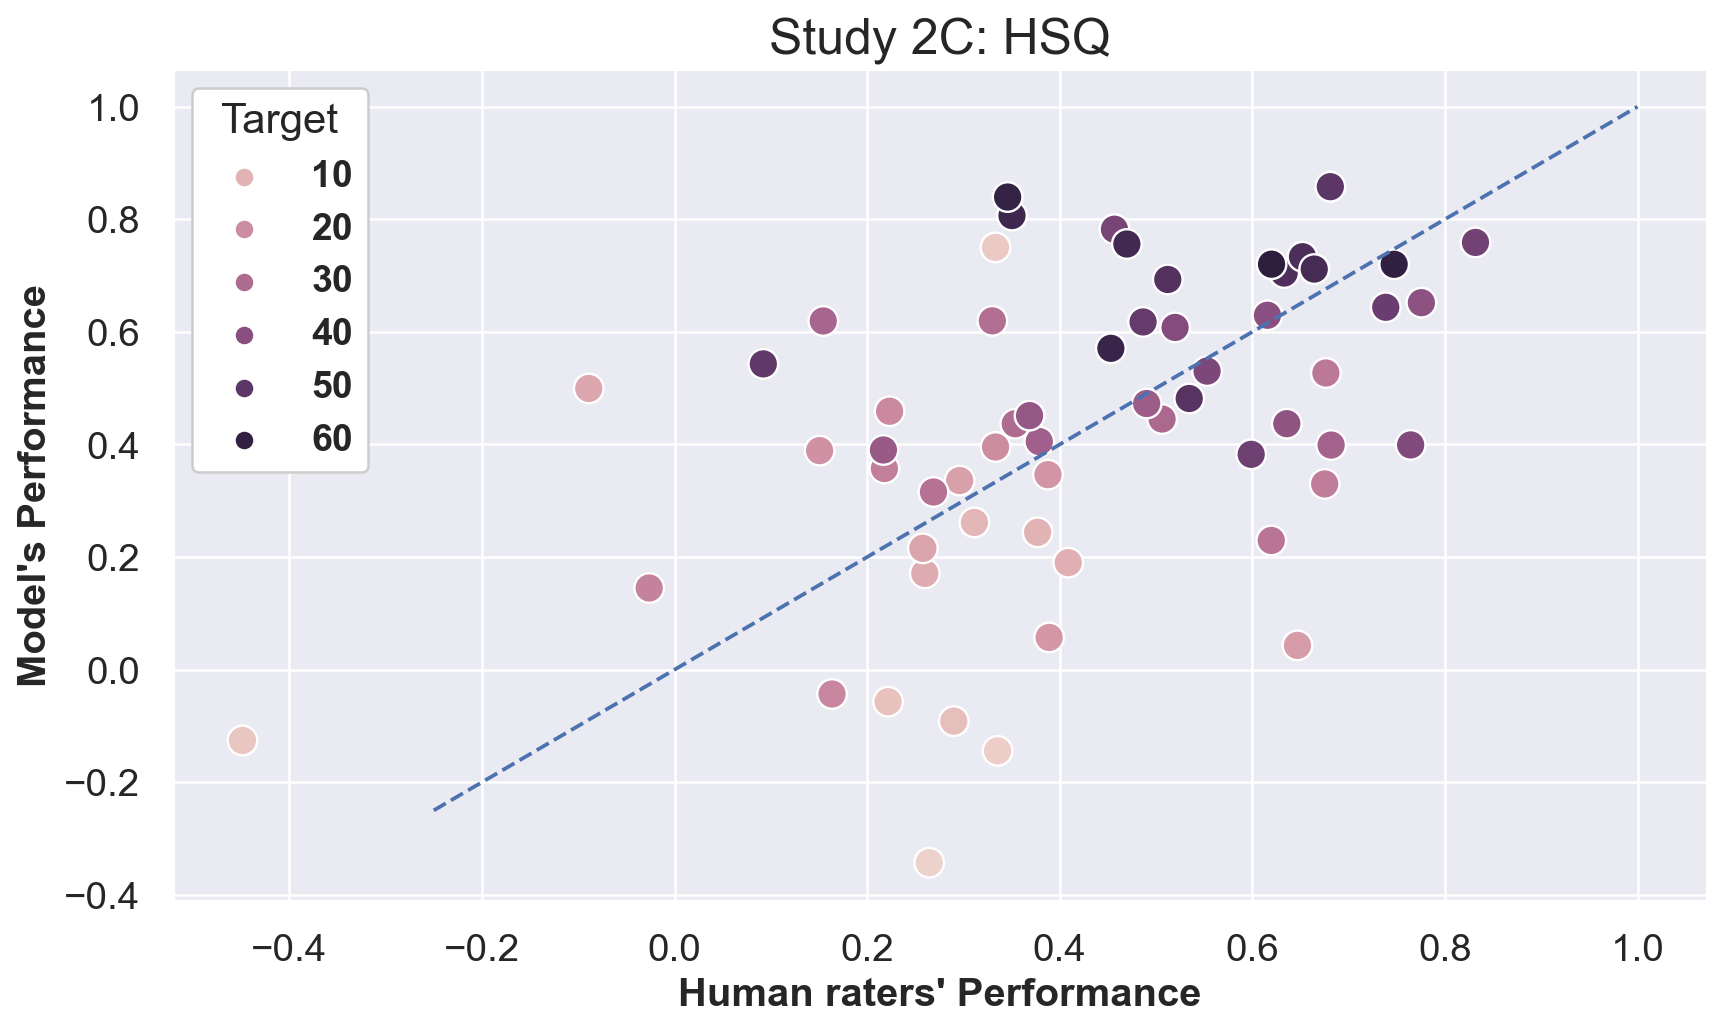

In [9]:
#update font size, etc
plt.style.use("seaborn-v0_8")
sns.set_context('paper')
sns.set(font_scale = 1.4)

for j, df_comparison in enumerate(df_comparisons):    
    # prep data
    df = df_comparison.loc[:, ["target", "Predictor", "Correlation"]] .groupby(["target", "Predictor"], as_index=False).aggregate("mean")
    df_scatter = df.pivot(index="target", columns='Predictor', values='Correlation').rename_axis(None, axis=1).reset_index()

    # scatter plot
    fig, ax = plt.subplots(figsize=(11, 6), dpi = 180) #figure specs
    sns.scatterplot(data=df_scatter, x="Human", y="Model", hue="target", s=140, alpha=1.0)

    # set labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Model\'s Performance', fontweight = "bold", fontsize=16)
    ax.set_xlabel('Human raters\' Performance', fontweight = "bold", fontsize=16)
    ax.legend(loc="upper left", frameon = True, framealpha = 1.0, facecolor='white', prop={'weight':'bold','size':15}, title="Target")
    ax.plot((-0.25, 1),(-0.25, 1), ls='--')
    plt.title(df_comparison.Dataset[0], fontsize=20)

    # save figures
    fig_name = "fig5_" + chr(65+2*j+1) + ".pdf" #start at B (big5 is A)
    plt.savefig("../plot_data/" + fig_name, bbox_inches='tight')
    
    # calculate correlation of human and model performance
    # drop NAs
    x = df_scatter.Human.dropna()
    y = df_scatter.Model[x.index].dropna()
    x = x[y.index].dropna()
    
    corr = pearsonr(x, y)
    print(corr)